# Analysis of Cartoon vs. Realistic Movie-watching Data

This notebook performs analyses on cartoon vs. realistic movies in infants and adults, and recreates figures in the manuscript. It uses files created from various scripts as described in the README and preprocessed fMRI data, assumed to be saved in `data/Movies/LionKing_*`.

Note: p values (and z-scores created through bootstrapping or randomization) may differ from those reported in the manuscript because of random seeds.

**Table of Contents**
>[Set up](#setup)  
>[Participant summary information](#descriptives)      
>[Create input data](#createinput)      
>[Intersubject correlation](#isc)    
>[Multivoxel pattern decoding](#mvpa)   
>[Supplementary analyses](#supp) 

## Set up <a id='setup'></a> 

Load packages and define some useful functions.

In [1]:
%matplotlib inline
%autosave 5


# suppress warning
import warnings 
warnings.filterwarnings('ignore')

# Import a bunch of stuff 
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np
import pickle
import pandas as pd
import sys
import os
import glob
import scipy
from scipy.io import loadmat
import scipy.stats as stats
from scipy.stats import norm, zscore, pearsonr, ttest_ind
from scipy.signal import gaussian, convolve
from scipy.spatial.distance import squareform
from sklearn import decomposition, preprocessing
from sklearn.model_selection import LeaveOneOut, RepeatedKFold
import seaborn as sns
import itertools
import nibabel as nib
from nilearn.input_data import NiftiMasker, NiftiLabelsMasker
from nilearn import plotting
from nilearn.image import mean_img
from nilearn import datasets
from nibabel.processing import conform
import pydicom as dicom
from brainiak.fcma.util import compute_correlation

# Modified isc brainiak scripts for infant data (i.e., deals with missing time points)
from modified_isc import *

# Get the base directory
curr_dir = os.getcwd()
os.chdir('../../') # Move into the infant neuropipe root
base_dir = os.getcwd() + '/'
os.chdir(curr_dir) # Come back

# set some paths that matter for this experiment 
save_plot_dir='%s/data/CartoonLive/plots/' %base_dir
live_data_folder=base_dir+'data/Movies/LionKing_Live/'
cartoon_data_folder=base_dir+'data/Movies/LionKing_Cartoon/'
live_data_funcs=live_data_folder+'preprocessed_standard/nonlinear_alignment/'
cartoon_data_funcs=cartoon_data_folder+'/preprocessed_standard/nonlinear_alignment/'

# Set some known variables 
nTRs=90 # we expect the data to be 90 TRs (3 minutes long) per movie
tr_shift=2 # shift the data by 2 TRs (4 seconds) to align to the movie frames

# set the color palette to be used (in the order of realistic then cartoon)
palette = ['#E9BC55','#E55924'] 

Autosaving every 5 seconds


### Define functions 

In [2]:
def bootstrap_mean(data,null_vall=0,nPerm=1000):
    np.random.seed(0)
    '''Bootstrap resampling for the mean of the data'''
    perm_dist=[]
    for perm in range(nPerm):
        sampidx=np.random.choice(np.arange(len(data)),len(data),replace=True)
        randomsamp=np.array(data)[sampidx]
        perm_dist.append(np.nanmean(randomsamp))
    
    # calculate 2 way pval
    if np.nanmean(data) < null_vall:
        pval=np.sum(np.array(perm_dist)>null_vall)/nPerm*2 
    else:
        pval=np.sum(np.array(perm_dist)<null_vall)/nPerm*2
        
    # If the value is greater than 1 then subtract 2
    if pval > 1:
        pval = 2 - pval
    
    CIs =[np.percentile(perm_dist, 2.5), np.percentile(perm_dist, 97.5)]
          
    return pval, CIs

def bootstrap_corr(x_data,y_data,nPerm=1000):
    '''Bootstrap resampling for the correlation between two variables'''
    
    corr_dist=[]
    
    # Occasionally may have NaNs so need to leave them out if true
    if sum(np.isnan(np.array(x_data))) > 0:
        print('X data contains %s NaNs' %(sum(np.isnan(np.array(x_data)))))
    if sum(np.isnan(np.array(y_data))) > 0:
        print('Y data contains %s NaNs' %(sum(np.isnan(np.array(y_data)))))       
    
    not_nan=np.where(~np.isnan(np.array(x_data))*~np.isnan(np.array(y_data)))[0]
    x_data=np.array(x_data)[not_nan]
    y_data=np.array(y_data)[not_nan]
    
    for perm in range(nPerm):
        sampidx=np.random.choice(np.arange(x_data.shape[0]),x_data.shape[0],replace=True)
        random_x=np.array(x_data)[sampidx]
        random_y=np.array(y_data)[sampidx]
        rval, pval=pearsonr(random_x,random_y)
        corr_dist.append(rval)
    
    # calculate 2 way pval
    if stats.pearsonr(x_data,y_data)[0] < 0:
        pval=np.sum(np.array(corr_dist)>=0)/nPerm*2
    else:
        pval=np.sum(np.array(corr_dist)<=0)/nPerm*2
        
    # If the value is greater than 1 then subtract 2
    if pval > 1:
        pval = 2 - pval
        
    CIs =[np.percentile(corr_dist, 2.5), np.percentile(corr_dist, 97.5)]
          
    return pval, CIs

def randomise_diff_2sample(data_1, data_2, resample_num=1000):        
    '''Bootstrap resampling independent samples. 
    Take N samples with replacement from each group separately, average within group and then subtract. 
    Do this X times and report the p value of the number of samples in the opposite direction 
    from the true effect'''
    
    # Resample the participants
    resample_diff = []
    for i in range(resample_num):
        
        # Determine what participants to use in the sample
        sub_idx_1 = np.random.randint(0, len(data_1), (1, len(data_1)))
        
        sub_idx_2 = np.random.randint(0, len(data_2), (1, len(data_2)))

        resample_diff += [np.nanmean(data_1[sub_idx_1]) - np.nanmean(data_2[sub_idx_2])]
    
    # calculate the 2 way p value
    p_val = (1 - ((np.sum(np.asarray(resample_diff) > 0)) / (resample_num))) * 2
    
    # If the value is greater than 1 then subtract 2
    if p_val > 1:
        p_val = 2 - p_val
    
    CIs =[np.percentile(resample_diff, 2.5), np.percentile(resample_diff, 97.5)]
    
    mean_diff = np.nanmean(data_1) - np.nanmean(data_2)
    
    # return the difference in ROI and 
    return p_val, mean_diff, CIs

def confound_TR_vec(confound_file, closed_file, vec_length, eye_shift=2):
    ''''Create a vector of TRs to be excluded for this half of the movie'''
    
    # "Load in the confound file and find the columns that have a value of 1 in them
    if confound_file != '':
        confound_data = np.loadtxt(confound_file, unpack=False, dtype=float)
        confound_idxs = np.where(confound_data==1)[0]

        # Do you want to exclude epochs where their eyes are closed
        if closed_file != '':

            # Load in the data                        
            closed_data = np.loadtxt(closed_file, delimiter=" ", unpack=False)
            
            # What TRs are excluded
            closed_eyes = np.where(closed_data==1)[0] + eye_shift # shift the eye tracking data
            
            # Update the confound idxs to be excluded
            confound_idxs = np.unique(np.append(confound_idxs, closed_eyes))
            
    else:
        confound_idxs = np.array([])

    # Preprocess the data
    if len(confound_idxs) > 0:

        # Bound the excluded TRs that are outside of the shape
        confound_idxs = confound_idxs[confound_idxs < vec_length]
        
        # Remove any that are under 0 for any reason
        confound_idxs = confound_idxs[confound_idxs >= 0]
        
    ppt_name = confound_file[confound_file.rfind('/') + 1:confound_file.rfind('.')]
    print('%s has %d %% of TRs excluded' % (ppt_name,(len(confound_idxs)/vec_length)*100)) #, confound_idxs)
    
    return confound_idxs

def brain_2_vec(data, mask, confound_idxs=None):
    '''Make a vector average from brain data'''
    # Take in data that is 4d and mask that is 4d. Confound idxs is a list of time points that are to be excluded
    
    # Pull out the data
    masked_data = data[mask == 1]
    masked_data = masked_data.reshape((int(mask.sum()), data.shape[3]))
    
    # Average the activity across voxels
    brain_vec = np.mean(masked_data, 0).flatten()
    
    # Turn the timepoints that aren't included into nan's
    if len(confound_idxs) > 0:
        brain_vec[confound_idxs] = np.nan
    
    # Return the vector map
    return brain_vec, masked_data

def preprocess_data(sub, movie_dir, brain_nii, nTRs=90):
    '''Preprocess movie data by excluding TRs for motion and eye tracking, averaging across within-session viewings if desired'''
    sub_nifti = nib.load(movie_dir +'preprocessed_standard/nonlinear_alignment/' + sub + '_Z.nii.gz').get_fdata() 
    sub_motion_confound = movie_dir +'motion_confounds/' + sub + '.txt'
    sub_eye_confound = movie_dir +'eye_confounds/' + sub + '.txt'

    confound_idxs = confound_TR_vec(sub_motion_confound, sub_eye_confound, nTRs)

    # mask the data
    brain_vec, brain_masked = brain_2_vec(sub_nifti, brain_nii.get_fdata(), confound_idxs)

    brain_masked=brain_masked.T # transpose to be TR x vox
    brain_masked[np.isnan(brain_vec),:]=np.nan # fill nans as needed
    
    return brain_masked

def preprocess_data_eyes(sub, movie_dir, brain_nii, nTRs=90):
    '''Preprocess movie data by excluding TRs for motion and eye tracking, averaging across within-session viewings if desired'''
    sub_nifti = nib.load(movie_dir +'smoothing0_sfnrmask-1/preprocessed_standard/nonlinear_alignment/' + sub + '_Z.nii.gz').get_fdata() 
    sub_motion_confound = movie_dir +'motion_confounds/' + sub + '.txt'
    sub_eye_confound = movie_dir +'eye_confounds/' + sub + '.txt'

    confound_idxs = confound_TR_vec(sub_motion_confound, sub_eye_confound, nTRs)

    # mask the data
    brain_vec, brain_masked = brain_2_vec(sub_nifti, eye_nii.get_fdata(), confound_idxs)

    brain_masked=brain_masked.T # transpose to be TR x vox
    brain_masked[np.isnan(brain_vec),:]=np.nan # fill nans as needed
    
    return brain_masked

def mvpa_trial_decoding_avg(con1_sub,con1_group,con2_sub,con2_group):
    '''Function that uses pattern similarity to decode whether a given patttern of activity from an individual 
    is more similar to the same condition from the group or the other condition'''
    
    #find the correlation between the correct vs. incorrect labels for condition 1 
    # NOTE: This assumes that the TRs are aligned across participants AND of equal length; these assumption are met in our data
    con1_con1_corr = [np.arctanh(np.corrcoef(con1_sub[tr],np.nanmean(con1_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con1_sub))]
    
    con1_con2_corr = [np.arctanh(np.corrcoef(con1_sub[tr],np.nanmean(con2_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con1_sub))]
    
    # Find binary accuracy for condition 1                      
    not_nans = (~np.isnan(con1_con1_corr)*~np.isnan(con1_con2_corr))
    con1_correct = np.array(con1_con1_corr)[not_nans] > np.array(con1_con2_corr)[not_nans]
    
    # find the correlation between the correct labels for condition 2
    con2_con2_corr = [np.arctanh(np.corrcoef(con2_sub[tr],np.nanmean(con2_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con2_sub))]
    
    con2_con1_corr = [np.arctanh(np.corrcoef(con2_sub[tr],np.nanmean(con1_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con2_sub))]
    
    # Find binary accuracy for condition 2                       
    not_nans = (~np.isnan(con2_con2_corr)*~np.isnan(con2_con1_corr))
    con2_correct = np.array(con2_con2_corr)[not_nans] > np.array(con2_con1_corr)[not_nans]
    
    # combine them                     
    sub_decoding = np.hstack((con1_correct,con2_correct))

    return np.mean(sub_decoding)


def mvpa_trial_decoding_3way_avg(con1_sub,con1_group,con2_sub,con2_group,con3_sub,con3_group):
    '''Function that uses pattern similarity to decode whether a given patttern of activity from an individual is more similar to the same condition from the group or the other condition'''
    
    #find the correlation between the correct vs. incorrect labels for condition 1 
    # NOTE: This assumes that the TRs are aligned across participants AND of equal length; these assumption are met in our data
    con1_con1_corr = [np.arctanh(np.corrcoef(con1_sub[tr],np.nanmean(con1_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con1_sub))]
    
    con1_con2_corr = [np.arctanh(np.corrcoef(con1_sub[tr],np.nanmean(con2_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con1_sub))]
    
    con1_con3_corr = [np.arctanh(np.corrcoef(con1_sub[tr],np.nanmean(con3_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con1_sub))]
    
    # Find binary accuracy for condition 1                      
    not_nans = (~np.isnan(con1_con1_corr)*~np.isnan(con1_con2_corr)*~np.isnan(con1_con3_corr))
    con1_correct = (np.array(con1_con1_corr)[not_nans] > 
                    np.array(con1_con2_corr)[not_nans])*(np.array(con1_con1_corr)[not_nans] 
                                                         > np.array(con1_con3_corr)[not_nans])
    
    # find the correlation between the correct labels for condition 2
    con2_con2_corr = [np.arctanh(np.corrcoef(con2_sub[tr],np.nanmean(con2_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con2_sub))]
    
    con2_con1_corr = [np.arctanh(np.corrcoef(con2_sub[tr],np.nanmean(con1_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con2_sub))]
    con2_con3_corr = [np.arctanh(np.corrcoef(con2_sub[tr],np.nanmean(con3_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con2_sub))]
        
    # Find binary accuracy for condition 2                     
    not_nans = (~np.isnan(con2_con2_corr)*~np.isnan(con2_con1_corr)*~np.isnan(con2_con3_corr))
    con2_correct = (np.array(con2_con2_corr)[not_nans] > 
                    np.array(con2_con1_corr)[not_nans])*(np.array(con2_con2_corr)[not_nans] > 
                    np.array(con2_con3_corr)[not_nans])
    
    # find the correlation between the correct labels for condition 3
    con3_con3_corr = [np.arctanh(np.corrcoef(con3_sub[tr],np.nanmean(con3_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con3_sub))]
    con3_con1_corr = [np.arctanh(np.corrcoef(con3_sub[tr],np.nanmean(con1_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con3_sub))]
    con3_con2_corr = [np.arctanh(np.corrcoef(con3_sub[tr],np.nanmean(con2_group,axis=0))[0,1]) # match TR 
                      for tr in np.arange(len(con3_sub))]
    
    # Find binary accuracy for condition 3             
    not_nans = (~np.isnan(con3_con3_corr)*~np.isnan(con3_con1_corr)*~np.isnan(con3_con2_corr))
    con3_correct = (np.array(con3_con3_corr)[not_nans] > 
                    np.array(con3_con1_corr)[not_nans])*(np.array(con3_con3_corr)[not_nans] > 
                    np.array(con3_con2_corr)[not_nans])
    
    # combine them                     
    sub_decoding = np.hstack((con1_correct,con2_correct,con3_correct))

    return np.mean(sub_decoding)

## Participant summary information  <a id='descriptives'></a> 
Load and report information about the infant and adult participants

### Infant participants

In [3]:
df = pd.read_csv('%s/data/Movies/LionKing_Cartoon/infant_participants.csv' %(base_dir))
df = df.sort_values(by='age').reset_index().drop(columns='index')
df

,ppt,age,sex,first_shown,Cartoon_num_TR,Cartoon_prop_TR_motion,Cartoon_prop_TR_eye,Cartoon_reliability,Live_num_TR,Live_prop_TR_motion,Live_prop_TR_eye,Live_reliability,coders
0,s5256_1_1,4.0,M,Cartoon,90,0.933333,0.868132,0.969928,70,0.728571,0.732394,0.908715,2
1,s4258_1_1,4.0,F,Cartoon,90,0.922222,0.956044,0.976067,90,0.933333,0.956044,0.976067,2
2,s3097_2_1,4.2,M,Cartoon,90,0.988889,0.967033,0.969378,90,0.855556,0.989011,0.972976,2
3,s7836_2_1,4.2,M,Cartoon,90,0.611111,0.912088,0.972348,90,0.755556,0.967033,0.946370,2
4,s6816_1_1,4.5,F,Cartoon,90,0.955556,1.000000,0.996759,90,0.822222,1.000000,0.965842,2
5,s3097_2_2,5.4,M,Cartoon,90,0.855556,0.791209,0.943557,90,0.577778,0.890110,0.962270,2
6,s4258_1_2,6.0,F,Cartoon,90,0.822222,0.945055,0.975528,90,0.877778,0.956044,0.988538,2
7,s2836_1_2,6.1,M,Live,90,1.000000,1.000000,0.983292,90,0.988889,1.000000,0.989338,2
8,s2816_1_1,6.7,M,Cartoon,90,0.977778,0.989011,0.983913,90,0.866667,0.923077,0.974220,2
9,s3097_2_3,6.8,M,Live,90,1.000000,1.000000,0.972859,90,1.000000,1.000000,0.908816,2


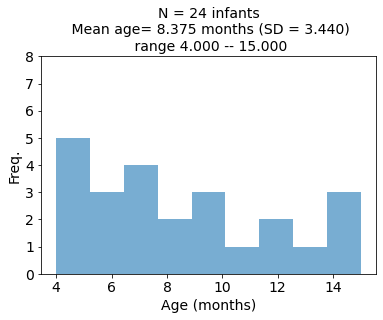

In [4]:
# Plot the age of the infants in the study
fig = plt.figure()
plt.hist(df.age,bins=9,alpha=0.6)
plt.title('N = %d infants\n Mean age= %0.3f months (SD = %0.3f)\n range %0.3f -- %0.3f' %(len(df),np.mean(df.age),
                                                 np.std(df.age),np.min(df.age),np.max(df.age)),fontsize=14)
plt.ylabel('Freq.',fontsize=14)
plt.xlabel('Age (months)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0,8)
fig.savefig(save_plot_dir+'age_distribution.svg')

In [5]:
# Print the average, sd, and range of values for various important data quality metrics 
for movie in ['Cartoon','Live']:
    print(movie)
    print('Mean TRs included for motion: M = %f SD = %f; range: %f -- %f' %(
        np.nanmean(df['%s_prop_TR_motion' % movie]),np.nanstd(df['%s_prop_TR_motion' % movie]),
        np.nanmin(df['%s_prop_TR_motion' % movie]),np.nanmax(df['%s_prop_TR_motion' % movie])))

    print('Mean TRs included for eye: M = %f SD = %f; range: %f -- %f' %(
        np.nanmean(df['%s_prop_TR_eye' % movie]),np.nanstd(df['%s_prop_TR_eye' % movie]),
        np.nanmin(df['%s_prop_TR_eye' % movie]),np.nanmax(df['%s_prop_TR_eye' % movie])))
    
    print('Mean IRR for gaze coders: M = %f SD = %f; range: %f -- %f' %(
        np.nanmean(df['%s_reliability' % movie]),np.nanstd(df['%s_reliability' % movie]),
        np.nanmin(df['%s_reliability' % movie]),np.nanmax(df['%s_reliability' % movie])))
  
    print()

Cartoon
Mean TRs included for motion: M = 0.910185 SD = 0.112533; range: 0.611111 -- 1.000000
Mean TRs included for eye: M = 0.913004 SD = 0.088818; range: 0.648352 -- 1.000000
Mean IRR for gaze coders: M = 0.966493 SD = 0.022184; range: 0.919008 -- 0.996759

Live
Mean TRs included for motion: M = 0.898413 SD = 0.121326; range: 0.577778 -- 1.000000
Mean TRs included for eye: M = 0.922000 SD = 0.100011; range: 0.681319 -- 1.000000
Mean IRR for gaze coders: M = 0.953938 SD = 0.041426; range: 0.861595 -- 0.997259



In [6]:
np.random.seed(0)

# Report informatino about the proportion of data usable after motion and gaze exclusion
for column in ['prop_TR_motion','prop_TR_eye']:

    pval, CIs  = bootstrap_mean(100*np.array(df['Cartoon_%s' % column] - df['Live_%s' % column]))
    print('Mean diff prop TR motion: %0.3f, CIs [%0.3f to %0.3f], p = %0.3f' %(100*np.mean(np.array(df['Cartoon_%s' % column] - df['Live_%s' % column])),
                                                                CIs[0],CIs[1],pval))

Mean diff prop TR motion: 1.177, CIs [-2.779 to 5.265], p = 0.624
Mean diff prop TR motion: -0.900, CIs [-4.488 to 2.809], p = 0.634


In [7]:
# preset
avg_fd=dict()

# Now let's use the motion parameters to check the framewise displacement values are similar

# cycle through movies
for movie in ['Cartoon','Live']:
    
    # preset
    avg_fd[movie]=dict()
    
    # cycle through participants
    for ppt in df.ppt:

        # load the motion parameters 
        motion_params=np.loadtxt('%s/data/Movies/LionKing_%s/raw_motion/%s_motion_params.txt' %(base_dir,movie,ppt))

        # if for some reason there is an extra column, delete it 
        if motion_params.shape[1]==7:
            motion_params=motion_params[:,:-1]

        # first, set aside the translational parameters
        translational_params= motion_params[:, :3]

        # then, convert the rotational parameters from degreees to radians
        # and multiply by a default brain radius (50 mm is used in FSL & Power et al., 2012)
        rotational_params= np.deg2rad(motion_params[:, 3:])*50

        # then calculate the difference between consecutive time points across parameters
        diff_displacements = np.diff(np.hstack((translational_params,rotational_params)), axis=0)
        
        # finally calculate FD as the sum of absolute differences
        fd = np.sum(np.abs(diff_displacements), axis=1)

        # get the median fd across time and save it 
        avg_fd[movie][ppt] = np.median(fd) 

np.random.seed(0)

cartoon_fd = np.array(list(avg_fd['Cartoon'].values()))
live_fd = np.array(list(avg_fd['Live'].values()))

print('Mean FD cartoon: %0.3f (SD = %0.3f)' %(np.mean(cartoon_fd),np.std(cartoon_fd)))

print('Mean FD live: %0.3f (SD = %0.3f)'%(np.mean(live_fd),np.std(live_fd)))

pval, CIs  = bootstrap_mean(cartoon_fd - live_fd)

print('Mean diff average FD: %0.3f, CIs [%0.3f to %0.3f], p = %0.3f' %(np.mean(cartoon_fd - live_fd),
                                                            CIs[0],CIs[1],pval))



Mean FD cartoon: 0.280 (SD = 0.224)
Mean FD live: 0.283 (SD = 0.234)
Mean diff average FD: -0.003, CIs [-0.061 to 0.055], p = 0.942


Diff in motion exclusion: M = -0.012, p = 0.624, CI = [-0.053 -- 0.028]


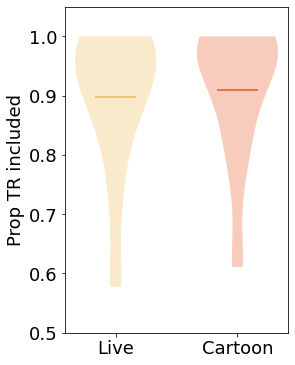

In [8]:
# Visualize the distribution for the proportion of proportion of usable TRs
fig = plt.figure(figsize=(4,6))
v = plt.violinplot([df['Live_prop_TR_motion'],df['Cartoon_prop_TR_motion']],
               positions=[0,0.75],showextrema=False,showmeans=True)

for pc, color in zip(v['bodies'], palette):
    pc.set_facecolor(color)
v['cmeans'].set_edgecolors(palette)
    
plt.xticks([0,0.75,],['Live','Cartoon'],fontsize=18)
plt.ylim(0.5,1.05)
plt.yticks(fontsize=18)
plt.ylabel('Prop TR included',fontsize=18)

fig.savefig(save_plot_dir+'motion_inclusion.svg')
np.random.seed(0)
mean_diff = np.mean(np.array(df['Live_prop_TR_motion'])-np.array(df['Cartoon_prop_TR_motion']))
pval,CIs=bootstrap_mean(np.array(df['Live_prop_TR_motion'])-np.array(df['Cartoon_prop_TR_motion']))

print('Diff in motion exclusion: M = %0.3f, p = %0.3f, CI = [%0.3f -- %0.3f]' % (mean_diff,pval, CIs[0],CIs[1]))

Diff in gaze inclusion: M = 0.009, p = 0.634, CI = [-0.028 -- 0.045]


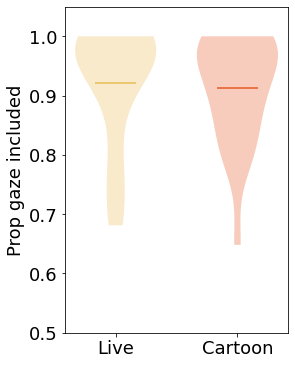

In [9]:
# Visualize the distribution for the proportion of eyes looking onscreen 
fig = plt.figure(figsize=(4,6))
v = plt.violinplot([df['Live_prop_TR_eye'],df['Cartoon_prop_TR_eye']],
               positions=[0,0.75],showextrema=False,showmeans=True,)

for pc, color in zip(v['bodies'], palette):
    pc.set_facecolor(color)
v['cmeans'].set_edgecolors(palette)
    
plt.xticks([0,0.75,],['Live','Cartoon'],fontsize=18)
plt.ylim(0.5,1.05)
plt.yticks(fontsize=18)
plt.ylabel('Prop gaze included',fontsize=18)

fig.savefig(save_plot_dir+'gaze_inclusion.svg')
np.random.seed(0)
mean_diff = np.mean(np.array(df['Live_prop_TR_eye'])-np.array(df['Cartoon_prop_TR_eye']))
pval,CIs=bootstrap_mean(np.array(df['Live_prop_TR_eye'])-np.array(df['Cartoon_prop_TR_eye']))

print('Diff in gaze inclusion: M = %0.3f, p = %0.3f, CI = [%0.3f -- %0.3f]' % (mean_diff,pval, CIs[0],CIs[1]))

### Adult participants

In [10]:
# load in the data for the adults 
adult_df = pd.read_csv('%s/data/Movies/LionKing_Cartoon/adult_participants.csv' %(base_dir))
adult_df = adult_df.sort_values(by='ppt').reset_index().drop(columns='index')
adult_df

,ppt,age,sex,first_shown,Cartoon_num_TR,Cartoon_prop_TR_motion,Live_num_TR,Live_prop_TR_motion,Cartoon_prop_TR_eye,Live_prop_TR_eye
0,rest_movie_01,19.0,F,Cartoon,90,1.0,90,1.0,NaN,NaN
1,rest_movie_02,23.0,M,Cartoon,90,1.0,90,1.0,NaN,NaN
2,rest_movie_03,19.0,F,Live,90,1.0,90,1.0,NaN,NaN
3,rest_movie_04,28.0,M,Live,90,1.0,90,1.0,NaN,NaN
4,rest_movie_05,29.0,F,Live,90,1.0,90,1.0,NaN,NaN
5,rest_movie_06,20.0,M,Cartoon,90,1.0,90,1.0,0.582418,0.956044
6,rest_movie_07,19.0,F,Cartoon,90,1.0,90,1.0,0.989011,0.989011
7,rest_movie_08,19.0,F,Cartoon,90,1.0,90,1.0,NaN,NaN
8,rest_movie_09,19.0,F,Live,90,1.0,90,1.0,NaN,NaN
9,rest_movie_10,20.0,M,Live,90,1.0,90,1.0,NaN,NaN


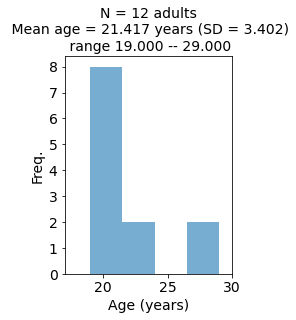

In [11]:
# Plot the age of the adults in the study
fig = plt.figure(figsize=(3,4))
plt.hist(adult_df.age,bins=4,alpha=0.6)
plt.title('N = %d adults\n Mean age = %0.3f years (SD = %0.3f)\n range %0.3f -- %0.3f' %(len(adult_df),np.mean(adult_df.age),
                                                 np.std(adult_df.age),np.min(adult_df.age),np.max(adult_df.age)),fontsize=14)
plt.xlim(17,30)
plt.ylabel('Freq.',fontsize=14)
plt.xlabel('Age (years)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
fig.savefig(save_plot_dir+'adult_age_distribution.svg')

## Create input data <a id='createinput'></a> 
NOTE: this section requires downloading preprocessed data or running the analysis pipeline for movie-watching on raw data. It is optional and does not need to be run since the numpy files it creates are available in the data folder.

Take in preprocessed fMRI data aligned to standard space, shift the data, remove motion and eye tracking exclusion TRs. This creates a numpy file that can be loaded in for other analyses.

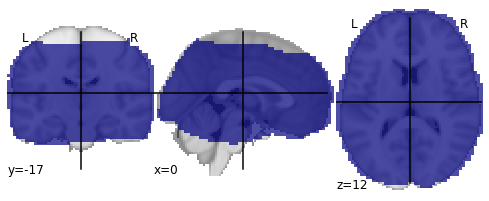

In [12]:
# Load the intersect brain mask (created with generate_intersect_mask)
mask='%s/data/CartoonLive/ROIs/intersect_mask_standard_LionKing_all.nii.gz' % base_dir # includes infants and adults
brain_nii=nib.load(mask)

# create a masker for this
brain_masker=NiftiMasker(mask_img=brain_nii)

# fit the masker 
test_sub=nib.load(mask)
test_fit=brain_masker.fit(test_sub)
affine_mat = test_sub.affine
dimsize = test_sub.header.get_zooms()
coords= np.where(brain_nii.get_fdata())

# plot the brain
plotting.plot_roi(brain_nii)

In [13]:
# If the path for the live data does not exist, create it 
if os.path.isfile(live_data_folder+'infants_wholebrain_data.pkl') == False:
    print('Creating preprocessed infant data for realistic movie')
    
    # Preset the live data dictionary
    live_data=dict()

    # get all files with a prefix s or LM (meaning that they are infant subjects)
    live_files=np.hstack((glob.glob(live_data_funcs+'s*'),glob.glob(live_data_funcs+'LM*')))

    print('LionKing Live')

    # cycle through the files
    for live_file in live_files:
        sub=live_file.split(live_data_funcs)[1].split('_functional')[0].split('_Z.nii.gz')[0] # find subject name 
        data=preprocess_data(sub,live_data_folder,brain_nii) # preprocess 
        data=data[tr_shift:nTRs+tr_shift] # shift the data to align to the movie
        live_data[sub]=stats.zscore(data,axis=0,nan_policy='omit') # don't forget to z-score over time

    # Save the data dictionary as a pkl file
    with open(live_data_folder+"infants_wholebrain_data.pkl", "wb") as file:
        pickle.dump(live_data, file)
    
# otherwise, load it in! 
else:
    print('Loading existing infant data for realistic movie')
    
    # Load the dictionary from the pickle file
    with open(live_data_folder+"infants_wholebrain_data.pkl", "rb") as f:
        live_data = pickle.load(f)

Loading existing infant data for realistic movie


In [14]:
# If the path for the cartoon data does not exist, create it 
if os.path.isfile(cartoon_data_folder+'infants_wholebrain_data.pkl') == False:

    print('Creating preprocessed infant data for cartoon movie')
    
    # Preset the cartoon data dictionary
    cartoon_data=dict()

    # get all files with a prefix s or LM (meaning they are infant subjects)
    cartoon_files=np.hstack((glob.glob(cartoon_data_funcs+'s*'),glob.glob(cartoon_data_funcs+'LM*')))

    print('\nLionKing Cartoon')

    # cycle through the files
    for cartoon_file in cartoon_files:
        sub=cartoon_file.split(cartoon_data_funcs)[1].split('_functional')[0].split('_Z.nii.gz')[0] # find subject name 
        data=preprocess_data(sub,cartoon_data_folder,brain_nii) # preprocess
        data=data[tr_shift:nTRs+tr_shift] # shift the data to align to the movie 
        cartoon_data[sub]=stats.zscore(data,axis=0,nan_policy='omit') # don't forget to z-score over time

# otherwise, load it in! 
else:
    print('Loading existing infant data for cartoon movie')
    
    # Load the dictionary from the pickle file
    with open(cartoon_data_folder+"infants_wholebrain_data.pkl", "rb") as f:
        cartoon_data = pickle.load(f)
        

Loading existing infant data for cartoon movie


In [15]:
# Get the dictionaries in the same order (works as long as all kids have each video)
live_data=dict(sorted(live_data.items()))
cartoon_data=dict(sorted(cartoon_data.items()))

# And then stack the files so they are easily manipulated for other analyses
live_stacked_data=np.stack([v for v in live_data.values()])
cartoon_stacked_data=np.stack([v for v in cartoon_data.values()])

In [16]:
# If the path for the adult live data does not exist, create it 
if os.path.isfile(live_data_folder+'adults_wholebrain_data.pkl') == False:
    print('Creating preprocessed adult data for realistic movie')
    
    # Preset the live data dictionary
    adult_live_data=dict()

    # get all files with a prefix rest (meaning that they are adult subjects)
    live_files=glob.glob(live_data_funcs+'rest*')

    print('LionKing Live')

    # cycle through the files
    for live_file in live_files:
        sub=live_file.split(live_data_funcs)[1].split('_functional')[0].split('_Z.nii.gz')[0] # find subject name 
        data=preprocess_data(sub,live_data_folder,brain_nii) # preprocess 
        data=data[tr_shift:nTRs+tr_shift] # shift the data to align to the movie
        adult_live_data[sub]=stats.zscore(data,axis=0,nan_policy='omit') # don't forget to z-score over time

    # Save the data dictionary as a pkl file
    with open(live_data_folder+"adults_wholebrain_data.pkl", "wb") as file:
        pickle.dump(adult_live_data, file)
    
# otherwise, load it in! 
else:
    print('Loading existing adult data for realistic movie')
    
    # Load the dictionary from the pickle file
    with open(live_data_folder+"adults_wholebrain_data.pkl", "rb") as f:
        adult_live_data = pickle.load(f)

Loading existing adult data for realistic movie


In [17]:
# If the path for the cartoon data does not exist, create it 
if os.path.isfile(cartoon_data_folder+'adults_wholebrain_data.pkl') == False:

    print('Creating preprocessed adult data for cartoon movie')
    
    # Preset the cartoon data dictionary
    adult_cartoon_data=dict()

    # get all files with a prefix rest (meaning they are adult subjects)
    cartoon_files=glob.glob(cartoon_data_funcs+'rest*')

    print('\nLionKing Cartoon')

    # cycle through the files
    for cartoon_file in cartoon_files:
        sub=cartoon_file.split(cartoon_data_funcs)[1].split('_functional')[0].split('_Z.nii.gz')[0] # find subject name 
        data=preprocess_data(sub,cartoon_data_folder,brain_nii) # preprocess
        data=data[tr_shift:nTRs+tr_shift] # shift the data to align to the movie 
        adult_cartoon_data[sub]=stats.zscore(data,axis=0,nan_policy='omit') # don't forget to z-score over time

    # Save the data dictionary as a pkl file
    with open(cartoon_data_folder+"adults_wholebrain_data.pkl", "wb") as file:
        pickle.dump(adult_cartoon_data, file)
        
# otherwise, load it in! 
else:
    print('Loading existing adult data for cartoon movie')
    
    # Load the dictionary from the pickle file
    with open(cartoon_data_folder+"adults_wholebrain_data.pkl", "rb") as f:
        adult_cartoon_data = pickle.load(f)
        

Loading existing adult data for cartoon movie


In [18]:
# Get the dictionaries in the same order (works as long as all adults have each video )
adult_live_data=dict(sorted(adult_live_data.items()))
adult_cartoon_data=dict(sorted(adult_cartoon_data.items()))

# And then stack the files so they are easily manipulated for other analyses
adult_live_stacked_data=np.stack([v for v in adult_live_data.values()])
adult_cartoon_stacked_data=np.stack([v for v in adult_cartoon_data.values()])

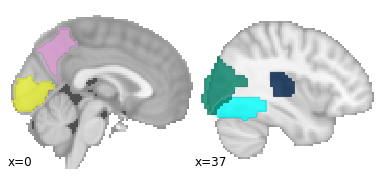

In [19]:
# Load the ROIs used in the ISC analyses
rois=['V1_combined','VO_combined','LO_combined','Precuneus_standard','EAC_standard']

# Colors for the ROIs
colors=[plt.get_cmap('plasma_r'),
        plt.get_cmap('cool'),
        plt.get_cmap('summer'),
        plt.get_cmap('tab20b_r'),
        plt.get_cmap('cividis'),
       plt.get_cmap('magma_r')]

# cycle through ROIs for visualization 
for r, roi in enumerate(rois):

    # Load in the standard ROI mask 
    roi_nii=nib.load(base_dir+'data/CartoonLive/ROIs/'+roi+'.nii.gz')

    # reformat it so it only includes intersect voxels
    roi_masked_nii=nib.Nifti1Image(roi_nii.get_fdata()*brain_nii.get_fdata(),roi_nii.affine)

    # make the masker 
    roi_masker=NiftiMasker(mask_img=roi_masked_nii)

    # fit the masker 
    _=roi_masker.fit(roi_nii)

    # plot!
    if r==0:
        fig = plotting.plot_roi(roi_masked_nii,cmap=colors[r],display_mode='x',
                           draw_cross=False,cut_coords=[0,37])
        fig.add_contours(roi_masked_nii,cmap='Greys',alpha=0.6,linewidths=0.1)
    else:
        fig.add_overlay(roi_masked_nii,cmap=colors[r],alpha=0.8)
        fig.add_contours(roi_masked_nii,cmap='Greys',alpha=0.6,linewidths=0.1)

# Save
fig.savefig(save_plot_dir+'rois_all.svg')

## Intersubject correlation <a id='isc'></a> 
How much stimulus-driven neural synchrony is there for each of the two movies?

### Infants 
Calculate intersubject correlation across the whole brain for infants 

In [22]:
# Calculate the intersubject correlations for each movie
# start with the realistic movie 
isc_live=isc(live_stacked_data.transpose(1,2,0)) # TR x vox x sub
mean_live=compute_summary_statistic(isc_live, summary_statistic='mean', axis=0)

# then the cartoon movie 
isc_cartoon=isc(cartoon_stacked_data.transpose(1,2,0)) # TR x vox x sub
mean_cartoon=compute_summary_statistic(isc_cartoon, summary_statistic='mean',axis=0)

In [23]:
analysis='temporal_isc' # Name of the analysis being run

# For each participant, if this data is not yet saved out, save it out 
# cycle through participants (NOTE this works because we sorted the dictionary earlier)
for p, ppt in enumerate(live_data.keys()):
    
    # does this subjects ISC file exist?
    if os.path.isfile('%s/data/Movies/LionKing_Live/%s/%s_Z.nii.gz' %(base_dir,analysis,ppt)) == False:
        
        print('saving realistic isc for %s'%ppt)
        
        # Live 
        isc_sub = isc_live[p]
        isc_sub_nii = brain_masker.inverse_transform(isc_sub)

        nib.save(isc_sub_nii,'%s/data/Movies/LionKing_Live/%s/%s.nii.gz' %(base_dir,analysis,ppt))
    
        # additionally save the fisher Z transformed file
        isc_sub_z_nii = brain_masker.inverse_transform(np.arctanh(isc_live[p]))
        nib.save(isc_sub_z_nii,'%s/data/Movies/LionKing_Live/%s/%s_Z.nii.gz' %(base_dir,analysis,ppt))
    
    # does this subjects ISC file exist?
    if os.path.isfile('%s/data/Movies/LionKing_Cartoon/%s/%s_Z.nii.gz' %(base_dir,analysis,ppt)) == False:
        
        print('saving cartoon isc for %s'%ppt)
        
        # Cartoon 
        isc_sub = isc_cartoon[p]
        isc_sub_nii = brain_masker.inverse_transform(isc_sub)

        nib.save(isc_sub_nii,'%s/data/Movies/LionKing_Cartoon/%s/%s.nii.gz' %(base_dir,analysis,ppt))
        
        # additionally save the fisher Z transformed file
        isc_sub_z_nii = brain_masker.inverse_transform(np.arctanh(isc_cartoon[p]))
        nib.save(isc_sub_z_nii,'%s/data/Movies/LionKing_Cartoon/%s/%s_Z.nii.gz' %(base_dir,analysis,ppt))

# inverse transform the mean ISC maps into whole brain maps 
live_nii=brain_masker.inverse_transform(mean_live)
cartoon_nii=brain_masker.inverse_transform(mean_cartoon)

# save them if they do not already exist
if os.path.isfile('%s/data/Movies/LionKing_Live/%s/infants_average.nii.gz' %(base_dir,analysis)) == False:
   
    nib.save(live_nii,'%s/data/Movies/LionKing_Live/%s/infants_average.nii.gz' %(base_dir,analysis))
else:
    print('mean whole brain map already created for realistic movie')

if os.path.isfile('%s/data/Movies/LionKing_Cartoon/%s/infants_average.nii.gz' %(base_dir,analysis)) == False:
   
    nib.save(cartoon_nii,'%s/data/Movies/LionKing_Cartoon/%s/infants_average.nii.gz' %(base_dir,analysis))
else:
    print('mean whole brain map already created for cartoon movie')

mean whole brain map already created for realistic movie
mean whole brain map already created for cartoon movie


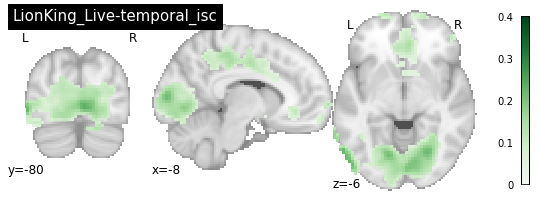

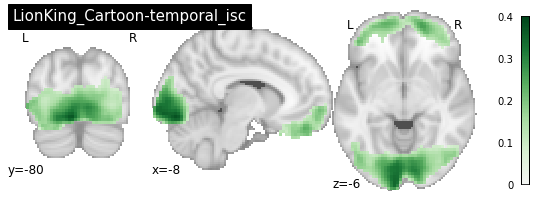

In [24]:
# Now, load in the corrected results after having run FSL randomise (on the command line, see README)
analysis='temporal_isc' # reminder, this is the temporal ISC analysis 
thr_type='tfce_corrp_tstat1' # TFCE corrected results from FSL

# cycle through movies 
for movie in ['LionKing_Live','LionKing_Cartoon']:
    
    # load the corrected file
    infant_isc_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_infants_%s.nii.gz'%
                               (movie,analysis,thr_type))

    # then, load the average ISC map 
    infant_isc_uncorr =  nib.load(base_dir+'data/Movies/%s/%s/infants_average.nii.gz' % (movie,analysis))

    # threshold the average ISC map to only show values that are significant after correction 
    infant_isc_thresholded = infant_isc_uncorr.get_fdata()
    infant_isc_thresholded[infant_isc_corr.get_fdata()<0.95]=0

    # turn this into a nifti
    infant_isc_stat_map = nib.Nifti1Image(infant_isc_thresholded,infant_isc_uncorr.affine)
        
    fig = plotting.plot_stat_map(infant_isc_stat_map,
                                 cmap='PRGn',vmax=0.4,
                                 title='%s-%s' % (movie,analysis),
                           cut_coords=(-8,-80,-6),draw_cross=False)
    
    fig.savefig(save_plot_dir+'/infant_%s_%s_%s.svg'% (analysis,movie.split('LionKing_')[-1].lower(),thr_type))

2.796939504772804


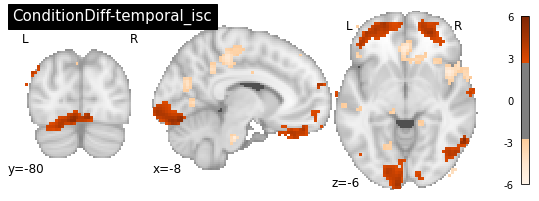

In [25]:
# Next, load in the results for the DIFFERENCE between movies 
# after having run FSL randomise (on the command line, see README)
# tstat1 = live > cartoon, tstat2 = cartoon > live 
analysis='temporal_isc' # reminder, this is the temporal ISC analysis 
thr_type='tstat2' # uncorrected map

# change the threshold / color if we are using a corrected 1-p value map 
if 'corrp' not in thr_type:

    # load the file 
    infant_isc_diff_stat_map = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz'%
                                        (analysis,thr_type))


    thresh=stats.t.ppf(0.995, len(df.ppt)) 
    print(thresh)
else:
    # load the corrected file
    infant_isc_diff_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz' %
                               (analysis,thr_type))

    # load the uncorrected file 
    infant_isc_diff_uncorr = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz' %
                                 (analysis,thr_type.split('corrp_')[-1]))

    # threshold it by the corrected file 
    infant_isc_diff_thresholded = infant_isc_diff_uncorr.get_fdata()
    infant_isc_diff_thresholded[infant_isc_diff_corr.get_fdata()<0.95]=0

    # turn it into a nifti
    infant_isc_diff_stat_map = nib.Nifti1Image(infant_isc_diff_thresholded,infant_isc_diff_uncorr.affine)

    thresh=np.min(infant_isc_thresholded[np.nonzero(infant_isc_thresholded)])
    print(thresh)

fig = plotting.plot_stat_map(infant_isc_diff_stat_map,threshold=thresh,
                             cmap='Oranges',vmax=6,
                             title='ConditionDiff-%s' % (analysis),cut_coords=(-8,-80,-6),
                       draw_cross=False)

fig.savefig(save_plot_dir+'/infant_%s_condition_diff_%s.svg'% (analysis,thr_type))

### Adults 

In [20]:
# Calculate the intersubject correlations for each movie for adults now 
# start with the realistic movie 
isc_live_adult=isc(adult_live_stacked_data.transpose(1,2,0)) # TR x vox x sub
mean_live_adult=compute_summary_statistic(isc_live_adult, summary_statistic='mean', axis=0)

# then the cartoon movie 
isc_cartoon_adult=isc(adult_cartoon_stacked_data.transpose(1,2,0)) # TR x vox x sub
mean_cartoon_adult=compute_summary_statistic(isc_cartoon_adult, summary_statistic='mean',axis=0)

In [22]:
analysis='temporal_isc' # Name of the analysis being run

# For each participant, if this data is not yet saved out, save it out 
# cycle through participants (NOTE this works because we sorted the dictionary earlier)
for p, ppt in enumerate(adult_live_data.keys()):
    
    # does this subjects ISC file exist?
    if os.path.isfile('%s/data/Movies/LionKing_Live/%s/%s_Z.nii.gz' %(base_dir,analysis,ppt)) == False:
        
        print('saving realistic isc for %s'%ppt)
        
        # Live 
        isc_sub = isc_live_adult[p]
        isc_sub_nii = brain_masker.inverse_transform(isc_sub)

        nib.save(isc_sub_nii,'%s/data/Movies/LionKing_Live/%s/%s.nii.gz' %(base_dir,analysis,ppt))
    
        # additionally save the fisher Z transformed file
        isc_sub_z_nii = brain_masker.inverse_transform(np.arctanh(isc_live_adult[p]))
        nib.save(isc_sub_z_nii,'%s/data/Movies/LionKing_Live/%s/%s_Z.nii.gz' %(base_dir,analysis,ppt))
    
    # does this subjects ISC file exist?
    if os.path.isfile('%s/data/Movies/LionKing_Cartoon/%s/%s_Z.nii.gz' %(base_dir,analysis,ppt)) == False:
        
        print('saving cartoon isc for %s'%ppt)
        
        # Cartoon 
        isc_sub = isc_cartoon_adult[p]
        isc_sub_nii = brain_masker.inverse_transform(isc_sub)

        nib.save(isc_sub_nii,'%s/data/Movies/LionKing_Cartoon/%s/%s.nii.gz' %(base_dir,analysis,ppt))
        
        # additionally save the fisher Z transformed file
        isc_sub_z_nii = brain_masker.inverse_transform(np.arctanh(isc_cartoon_adult[p]))
        nib.save(isc_sub_z_nii,'%s/data/Movies/LionKing_Cartoon/%s/%s_Z.nii.gz' %(base_dir,analysis,ppt))

# inverse transform the mean ISC maps into whole brain maps 
live_nii=brain_masker.inverse_transform(mean_live_adult)
cartoon_nii=brain_masker.inverse_transform(mean_cartoon_adult)

# save them if they do not already exist
if os.path.isfile('%s/data/Movies/LionKing_Live/%s/adults_average.nii.gz' %(base_dir,analysis)) == False:
   
    nib.save(live_nii,'%s/data/Movies/LionKing_Live/%s/adults_average.nii.gz' %(base_dir,analysis))
else:
    print('mean whole brain map already created for realistic movie')

if os.path.isfile('%s/data/Movies/LionKing_Cartoon/%s/adults_average.nii.gz' %(base_dir,analysis)) == False:
   
    nib.save(cartoon_nii,'%s/data/Movies/LionKing_Cartoon/%s/adults_average.nii.gz' %(base_dir,analysis))
else:
    print('mean whole brain map already created for cartoon movie')

mean whole brain map already created for realistic movie
mean whole brain map already created for cartoon movie


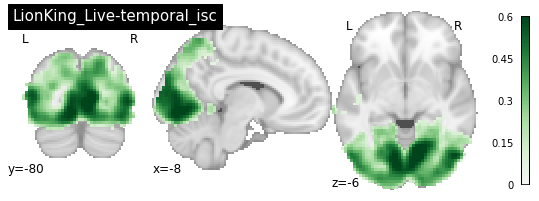

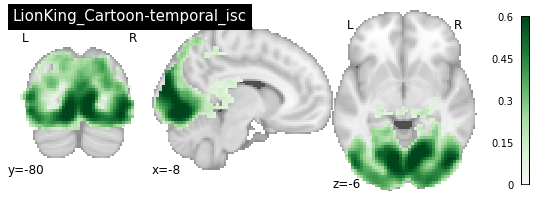

In [24]:
# Now, load in the corrected results after having run FSL randomise (on the command line, see README)
analysis='temporal_isc' # reminder, this is the temporal ISC analysis 
thr_type='tfce_corrp_tstat1' # TFCE corrected results from FSL

# cycle through the movies 
for movie in ['LionKing_Live','LionKing_Cartoon']:
    
    # load the corrected file
    adult_isc_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_adults_%s.nii.gz'%
                               (movie,analysis,thr_type))

    # then, load the average ISC map 
    adult_isc_uncorr =  nib.load(base_dir+'data/Movies/%s/%s/adults_average.nii.gz' % (movie,analysis))

    # threshold the average ISC map to only show values that are significant after correction 
    adult_isc_thresholded = adult_isc_uncorr.get_fdata()
    adult_isc_thresholded[adult_isc_corr.get_fdata()<0.95]=0

    # turn it into a nifti
    adult_isc_stat_map = nib.Nifti1Image(adult_isc_thresholded,adult_isc_uncorr.affine)
   
    fig = plotting.plot_stat_map(adult_isc_stat_map,
                                 cmap='PRGn',vmax=0.6,
                                 title='%s-%s' % (movie,analysis),
                           cut_coords=(-8,-80,-6),draw_cross=False)
    
    fig.savefig(save_plot_dir+'/adult_%s_%s_%s.svg'% (analysis,movie.split('LionKing_')[-1].lower(),thr_type))

3.0545395883368704


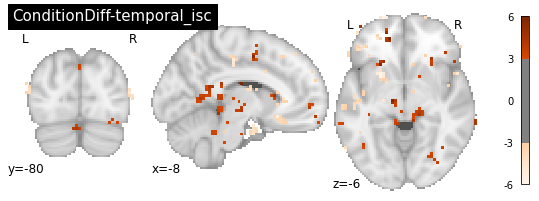

In [25]:
# Next, load in the results for the DIFFERENCE between movies 
# after having run FSL randomise (on the command line, see README)
# tstat1 = live > cartoon, tstat2 = cartoon > live 
analysis='temporal_isc' # reminder, this is the temporal ISC analysis 
thr_type='tstat2' # uncorrected map

# change the threshold / color if we are using a corrected 1-p value map 
if 'corrp' not in thr_type:

    # load the file 
    adult_isc_diff_stat_map = nib.load(base_dir+'data/CartoonLive/randomise/%s_adults_condition_diff_%s.nii.gz'%
                                        (analysis,thr_type))


    thresh=stats.t.ppf(0.995, len(adult_df.ppt)) # remember, use the adults here
    print(thresh)
else:
    # load the corrected file
    adult_isc_diff_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_adults_condition_diff_%s.nii.gz' %
                               (analysis,thr_type))

    # load the uncorrected file 
    adult_isc_diff_uncorr = nib.load(base_dir+'data/CartoonLive/randomise/%s_adults_condition_diff_%s.nii.gz' %
                                 (analysis,thr_type.split('corrp_')[-1]))

    # threshold it by the corrected file 
    adult_isc_diff_thresholded = adult_isc_diff_uncorr.get_fdata()
    adult_isc_diff_thresholded[adult_isc_diff_corr.get_fdata()<0.95]=0

    # turn it into a nifti
    adult_isc_diff_stat_map = nib.Nifti1Image(adult_isc_diff_thresholded,adult_isc_diff_uncorr.affine)

fig = plotting.plot_stat_map(adult_isc_diff_stat_map,threshold=thresh,
                             cmap='Oranges',vmax=6,
                             title='ConditionDiff-%s' % (analysis),cut_coords=(-8,-80,-6),
                       draw_cross=False)

fig.savefig(save_plot_dir+'/adult_%s_condition_diff_%s.svg'% (analysis,thr_type))

### ROI analysis
For both infants and adults, what does ISC look like in different visual and non-visual ROIs?

V1_combined
Infants live: M = 0.098, CI = [0.055 to 0.141], p=0.000
Adults live: M = 0.394, CI = [0.343 to 0.444], p=0.000
Infants cartoon: M = 0.178, CI = [0.123 to 0.238], p=0.000
Adults cartoon: M = 0.401, CI = [0.326 to 0.472], p=0.000

Infants diff in cartoon vs. live: M = -0.080, CI = [-0.142 to -0.024], p=0.000
Adults diff in cartoon vs. live: M = -0.007, CI = [-0.058 to 0.043], p=0.800
Infants corr with age live: r=-0.069, p=0.762
Infants corr with age cartoon: r=0.267,  p=0.242

VO_combined
Infants live: M = 0.083, CI = [0.044 to 0.127], p=0.000
Adults live: M = 0.308, CI = [0.262 to 0.360], p=0.000
Infants cartoon: M = 0.084, CI = [0.041 to 0.127], p=0.000
Adults cartoon: M = 0.333, CI = [0.266 to 0.392], p=0.000

Infants diff in cartoon vs. live: M = -0.001, CI = [-0.055 to 0.051], p=0.970
Adults diff in cartoon vs. live: M = -0.025, CI = [-0.072 to 0.022], p=0.314
Infants corr with age live: r=0.097, p=0.600
Infants corr with age cartoon: r=0.436,  p=0.046

LO_combined
Infa

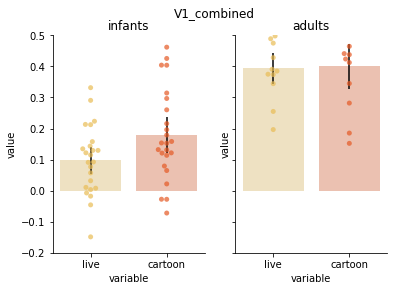

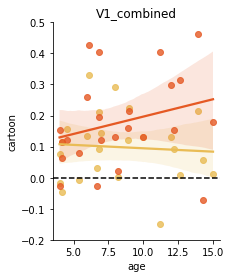

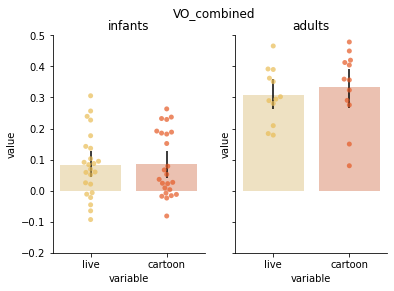

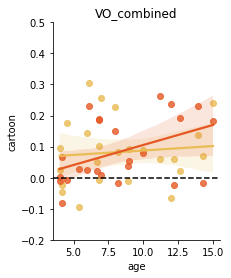

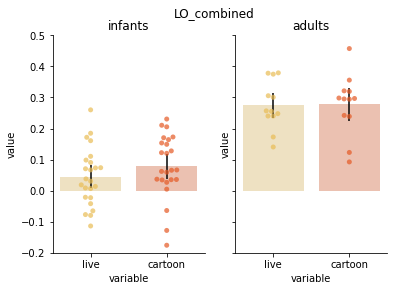

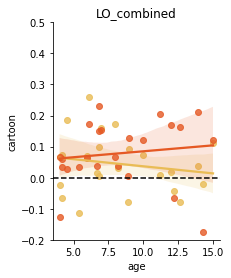

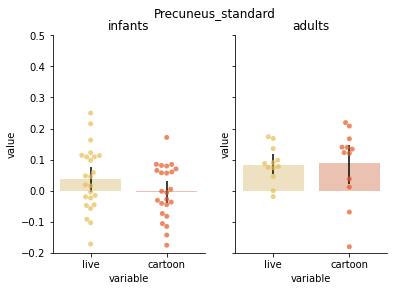

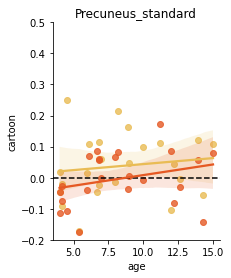

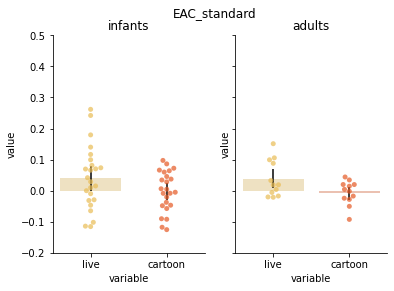

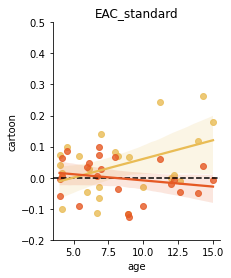

In [26]:
## ROI analysis
analysis='temporal_isc' # reminder, temporal_isc

# cycle through the ROIs
for roi in rois:
    print(roi)
   
    # load the ROI
    roi_nii=nib.load(base_dir+'data/CartoonLive/ROIs/'+roi+'.nii.gz')
                     
    # reformat it so it only includes intersect voxels
    roi_masked_nii=nib.Nifti1Image(roi_nii.get_fdata()*brain_nii.get_fdata(),roi_nii.affine)

    # make the masker 
    roi_masker=NiftiMasker(mask_img=roi_masked_nii)

    # fit the masker 
    _=roi_masker.fit(roi_nii)

    ####### Analysis

    np.random.seed(0)

    #### Infants 
    sub_ages = []
    sub_isc_vols_live = [] 
    sub_isc_vols_cartoon = [] 

    # get the files we created above for the live condition
    infant_sub_isc_files_live = np.sort(np.hstack((glob.glob(base_dir+'data/Movies/LionKing_Live/'+analysis+'/s*_Z.nii.gz'),
                                           glob.glob(base_dir+'data/Movies/LionKing_Live/'+analysis+'/LM*_Z.nii.gz'))))
    for file in infant_sub_isc_files_live:

        sub_nii = nib.load(file)
        sub_isc = sub_nii.get_fdata()[roi_nii.get_fdata()==1]
        sub_isc_vols_live.append(sub_isc)

        # also get their ages 
        sub_id = file.split('/')[-1].split('_Z.nii.gz')[0]
        sub_ages.append(float(df.age[df.ppt == sub_id]))

    sub_isc_vols_live = np.stack(sub_isc_vols_live)
    
    # get the files we above created for the cartoon condition
    infant_sub_isc_files_cartoon = np.sort(np.hstack((glob.glob(base_dir+'data/Movies/LionKing_Cartoon/'+analysis+'/s*_Z.nii.gz'),
                                           glob.glob(base_dir+'data/Movies/LionKing_Cartoon/'+analysis+'/LM*_Z.nii.gz'))))
    for file in infant_sub_isc_files_cartoon:

        sub_nii = nib.load(file)

        sub_isc = sub_nii.get_fdata()[roi_nii.get_fdata()==1]
        sub_isc_vols_cartoon.append(sub_isc)

    sub_isc_vols_cartoon = np.stack(sub_isc_vols_cartoon)

    # dont forget to inverse fisher z transform after averaging
    temp_df=pd.DataFrame({'live':np.tanh(np.nanmean(sub_isc_vols_live,axis=1)),
                 'cartoon':np.tanh(np.nanmean(sub_isc_vols_cartoon,axis=1)),'age':sub_ages})

    #### Adults 
    adult_sub_isc_vols_live = [] 
    adult_sub_isc_vols_cartoon = [] 

    # get the files we created above for the live condition
    adult_sub_isc_files_live = np.sort(glob.glob(base_dir+'data/Movies/LionKing_Live/'+analysis+'/r*_Z.nii.gz'))
    for file in adult_sub_isc_files_live:
        sub_nii = nib.load(file)

        sub_isc = sub_nii.get_fdata()[roi_nii.get_fdata()==1]
        adult_sub_isc_vols_live.append(sub_isc)

    adult_sub_isc_vols_live = np.stack(adult_sub_isc_vols_live)


    # get the files we created above for the cartoon condition
    adult_sub_isc_files_cartoon = np.sort(glob.glob(base_dir+'data/Movies/LionKing_Cartoon/'+analysis+'/r*_Z.nii.gz'))
    for file in adult_sub_isc_files_cartoon:
        sub_nii = nib.load(file)

        sub_isc = sub_nii.get_fdata()[roi_nii.get_fdata()==1]
        adult_sub_isc_vols_cartoon.append(sub_isc)

    adult_sub_isc_vols_cartoon = np.stack(adult_sub_isc_vols_cartoon)

    # dont forget to inverse fisher z transform after averaging
    temp_df_adult=pd.DataFrame({'live':np.tanh(np.nanmean(adult_sub_isc_vols_live,axis=1)),
                 'cartoon':np.tanh(np.nanmean(adult_sub_isc_vols_cartoon,axis=1))})

    ###### Plot 
    fig, ax=plt.subplots(1,2,figsize=(6,4),sharey=True)
    fig.suptitle('%s' %(roi))
    
    # Hide the top and right spines
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    
    # Infant subplot 
    ax[0].set_title('infants')
    ax[0].set_ylim(-0.2,0.5)
    
    # Plot the data
    sns.barplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.4,
                order=['live','cartoon'],ax=ax[0],ci=None)
    sns.swarmplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.7,
                order=['live','cartoon'],ax=ax[0])
    
    # Adult subplot 
    ax[1].set_title('adults')
    ax[1].set_ylim(-0.2,0.5)
    
    # Plot the data
    sns.barplot(x='variable',y='value',data=temp_df_adult.melt(),palette=palette,alpha=0.4,
                order=['live','cartoon'],ax=ax[1],ci=None)
    sns.swarmplot(x='variable',y='value',data=temp_df_adult.melt(),palette=palette,alpha=0.7,
                order=['live','cartoon'],ax=ax[1])
    
    # report the statistics as well 
    for m, movie in enumerate(['live','cartoon']):
        
        # infants first 
        pval, CIs=bootstrap_mean(temp_df[movie],null_vall=0)

        print('Infants %s: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % (movie,np.mean(temp_df[movie]),
                                                                       CIs[0],CIs[1],
                                                                       pval))
        # use our CI, rather than the built in function for plotting 
        ax[0].errorbar(m,np.nanmean(temp_df[movie]),
                 yerr=(np.abs(np.nanmean(temp_df[movie])-np.array(CIs))).reshape(-1,1),
                     fmt='none',ecolor='k')
        
        # then adults 
        pval, CIs=bootstrap_mean(temp_df_adult[movie],null_vall=0)

        print('Adults %s: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % (movie,np.mean(temp_df_adult[movie]),
                                                                       CIs[0],CIs[1],
                                                                       pval))
        # use our CI, rather than the built in function for plotting
        ax[1].errorbar(m,np.nanmean(temp_df_adult[movie]),
                 yerr=(np.abs(np.nanmean(temp_df_adult[movie])-np.array(CIs))).reshape(-1,1),
                     fmt='none',ecolor='k')
   
    # report the movie differences for each 
    print()
    p_diff, CIs=bootstrap_mean(np.array(temp_df['live']) 
                               - np.array(temp_df['cartoon']),null_vall=0,nPerm=1000)
    print('Infants diff in cartoon vs. live: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % 
                                      (np.mean(np.array(temp_df['live']) - np.array(temp_df['cartoon'])),
                                                                       CIs[0],CIs[1],
                                                                       p_diff))

    p_diff, CIs=bootstrap_mean(np.array(temp_df_adult['live']) - np.array(temp_df_adult['cartoon']),null_vall=0,nPerm=1000)
    print('Adults diff in cartoon vs. live: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % 
                                      (np.mean(np.array(temp_df_adult['live']) - np.array(temp_df_adult['cartoon'])),
                                                                       CIs[0],CIs[1],
                                                                       p_diff))

    # save the figure! 
    fig.savefig('%s/infants_adults_%s_%s.svg' %(save_plot_dir,roi,analysis))
    
    ####### Infant age effects 
    # Within the two conditions 
    fig, ax=plt.subplots(1,1,figsize=(3,4),sharey=True)
    plt.title(roi)
    plt.xlim(3.5,15.5) # age range
    plt.ylim(-0.2,0.5) # same y-range for ISC as in other plot 
    plt.ylabel('isc')
    plt.axhline(0,linestyle='dashed',color='black')

    # actually plot the data
    sns.regplot(x='age',y='live',data=temp_df,color=palette[0],label='live')
    sns.regplot(x='age',y='cartoon',data=temp_df,color=palette[1],label='cartoon')
   
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Report the stats
    p, CIs=bootstrap_corr(np.array(temp_df['age']),np.array(temp_df['live']),nPerm=1000)
    print('Infants corr with age live: r=%0.3f, p=%0.3f' %(stats.pearsonr(np.array(temp_df['age']),np.array(temp_df['live']))[0],p))

    p, CIs=bootstrap_corr(np.array(temp_df['age']),np.array(temp_df['cartoon']),nPerm=1000)
    print('Infants corr with age cartoon: r=%0.3f,  p=%0.3f' %(stats.pearsonr(np.array(temp_df['age']),np.array(temp_df['cartoon']))[0],p))

    # save the figure 
    fig.savefig('%s/infants_age_%s_%s.svg' %(save_plot_dir,roi,analysis))
   
    print()
    

## Multivoxel pattern decoding <a id='mvpa'></a> 
How well can we use patterns of brain activity to predict visual features in the movies for a held-out participant?

In [20]:
# First load in the hand-coded regressors for each of the two movies 
# Note that these do not need to be shifted at all, they start at the time of the movie start
cartoonlive_regressors = pd.read_csv('%s/data/CartoonLive/CartoonLive_Regressors.csv' % base_dir)
cartoonlive_regressors.head()

,Time Start (s),Faces - Live,Faces - Cartoon,Scene - Live,Scene - Cartoon,Main Animal - Live,Main Animal - Cartoon,Num Animals - Live,Num Animals - Cartoon
0,0,No,No,Far,Far,NaN,NaN,0,0
1,2,No,No,Far,Far,NaN,NaN,0,0
2,4,No,No,Far,Far,NaN,NaN,0,0
3,6,No,No,Far,Far,NaN,NaN,0,0
4,8,No,No,Far,Far,NaN,NaN,0,0


### Faces
Can we decode face presence vs. absence in the two movies?

Live -- Face present?
No 34
Yes 56

Cartoon -- Face present?
No 33
Yes 57



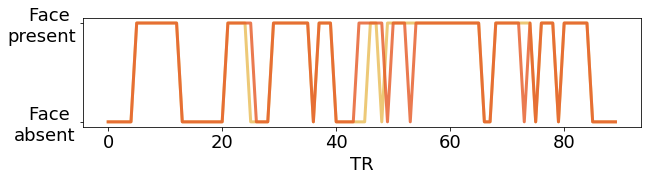

In [21]:
# Plot the regressors for faces -- separately for live and cartoon 
fig = plt.figure(figsize=(10,2))
plt.plot(np.array(list(cartoonlive_regressors['Faces - %s' % 'Live'])),color=palette[0],linewidth=3,alpha=0.8)
plt.plot(np.array(list(cartoonlive_regressors['Faces - %s' % 'Cartoon'])),color=palette[1],linewidth=3,alpha=0.8)
plt.yticks(fontsize=16)
plt.yticks([0,1],['Face \nabsent','Face \npresent'],fontsize=18)
plt.xticks(fontsize=18)
plt.xlabel('TR',fontsize=18)

fig.savefig(save_plot_dir+'faces_timecourse.svg')

# Cycle through the movies and report the number of examples of each condition
for movie in ['Live','Cartoon']:
    print(movie,'-- Face present?')

    # what regressor are we using? 
    regressor = np.array(list(cartoonlive_regressors['Faces - %s' % movie]))
    for unique in np.unique(regressor):
        print(unique,sum(regressor==unique))
    print()

VO_combined
Classification of faces during Live: 0.530, CIs = [0.500 to 0.563], pval = 0.054
Classification of faces during Cartoon: 0.567, CIs = [0.547 to 0.587], pval = 0.000
Difference: -0.037, CIs = [-0.072 to -0.004], pval = 0.020
Infants corr with age live: r=0.220, p=0.202
Infants corr with age cartoon: r=-0.177,  p=0.284

bilateral_FFA
Classification of faces during Live: 0.523, CIs = [0.492 to 0.551], pval = 0.148
Classification of faces during Cartoon: 0.538, CIs = [0.515 to 0.561], pval = 0.000
Difference: -0.016, CIs = [-0.049 to 0.018], pval = 0.386
Infants corr with age live: r=0.027, p=0.878
Infants corr with age cartoon: r=0.403,  p=0.038

bilateral_PPA
Classification of faces during Live: 0.542, CIs = [0.510 to 0.574], pval = 0.008
Classification of faces during Cartoon: 0.536, CIs = [0.510 to 0.566], pval = 0.010
Difference: 0.006, CIs = [-0.043 to 0.051], pval = 0.792
Infants corr with age live: r=-0.079, p=0.712
Infants corr with age cartoon: r=0.096,  p=0.756



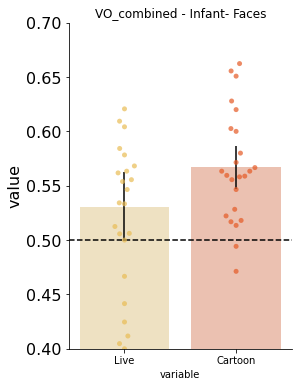

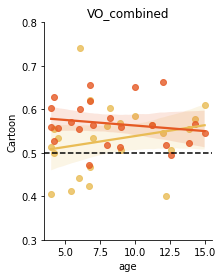

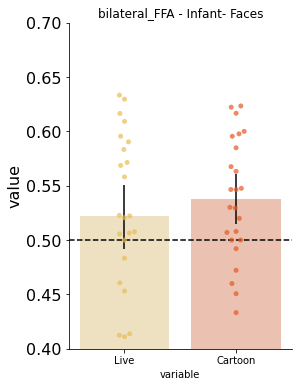

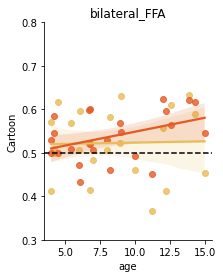

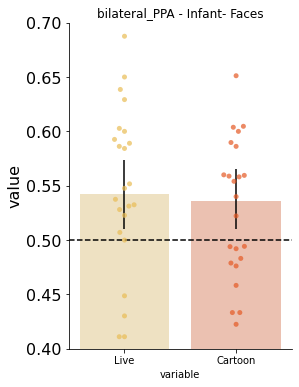

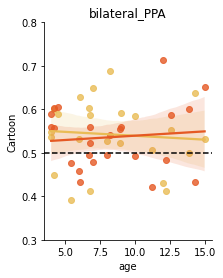

In [25]:
# Preset a LOO for the cross-validation
loo=LeaveOneOut()

# set a random seed
np.random.seed(0)

# Cycle through the ROIs
for roi in ['VO_combined','bilateral_FFA','bilateral_PPA']:
    
    print(roi)

    # Load in the standard ROI mask (in 3mm space)
    roi_nii=nib.load(base_dir+'data/CartoonLive/ROIs/'+roi+'.nii.gz')
    
    # get the ROI values by using the brain masker on the ROI
    roi_vals = brain_masker.fit_transform(roi_nii)[0]

    # only get the values for this ROI for the infant data
    infant_live_roi = live_stacked_data[:,:,roi_vals==1]
    infant_cartoon_roi = cartoon_stacked_data[:,:,roi_vals==1]

    # preset a dictionary for the decoding results
    decoding_dict = dict()
    
    # Cycle through the movies 
    for movie in ['Live','Cartoon']:
        
        # which regressor are we using? 
        regressor = np.array(list(cartoonlive_regressors['Faces - %s' % movie]))

        # get the data according to which movie 
        if movie == 'Live':
            data_roi = infant_live_roi
        else:
            data_roi = infant_cartoon_roi

        # preset
        decoding_accuracy = []
        sub_ages=[]

        # For each possible subject
        for _, sub in loo.split(data_roi):

            # Get the average pattern of activity for this infant for the two conditions
            sub_face_pattern = data_roi[sub[0]][regressor=='Yes']
            sub_no_face_pattern = data_roi[sub[0]][regressor=='No']

            # Get the average pattern of activity for all OTHER infants for the two conditions
            average_face_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='Yes'],axis=0)
            average_no_face_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='No'],axis=0)

            # Run the MVPA trial decoding 
            sub_decoding = mvpa_trial_decoding_avg(sub_face_pattern,average_face_pattern,
                                              sub_no_face_pattern,average_no_face_pattern,)

            # add subjects' decoding value to the list
            decoding_accuracy.append(sub_decoding)
            
            # add the age as well 
            # (only works because the infant_live_roi and infant_cartoon_roi arrays are in the same order as the dictionary)
            sub_ages.append(list(df.age[df.ppt==list(cartoon_data.keys())[sub[0]]])[0])

        # add all of this to the dictionary 
        decoding_dict[movie]=decoding_accuracy
        
    # preset a plot
    fig,ax = plt.subplots(figsize=(4,6))

    # plot the results 
    plt.title('%s - Infant- Faces' %(roi))
    plt.ylim(0,1)
    plt.axhline(0.5,linestyle='--',color='k')
    plt.ylabel('classification accuracy',fontsize=16)
    plt.yticks(fontsize=16)
    
    # Plot the results
    sns.barplot(x='variable',y='value',data=pd.DataFrame(decoding_dict).melt(),palette=palette,alpha=0.4,
                order=['Live','Cartoon'],ci=None)
    sns.swarmplot(x='variable',y='value',data=pd.DataFrame(decoding_dict).melt(),palette=palette,alpha=0.7,
                order=['Live','Cartoon'])
    plt.ylim(0.4,0.7)


    # report the statistics as well 
    for m, movie in enumerate(['Live','Cartoon']):
        pval, CIs=bootstrap_mean(decoding_dict[movie],null_vall=0.5)

        print('Classification of faces during %s: %0.3f, CIs = [%0.3f to %0.3f], pval = %0.3f' %
              (movie,np.nanmean(decoding_dict[movie]),CIs[0],CIs[1],pval))

        plt.errorbar(m,np.nanmean(decoding_dict[movie]),
                 yerr=(np.abs(np.nanmean(decoding_dict[movie])-np.array(CIs))).reshape(-1,1),
                     fmt='none',ecolor='k') #use our CI

    pval,CIs =bootstrap_mean(np.array(decoding_dict['Live'])-np.array(decoding_dict['Cartoon']),null_vall=0)
    print('Difference: %0.3f, CIs = [%0.3f to %0.3f], pval = %0.3f' %(np.mean(np.array(decoding_dict['Live'])-np.array(decoding_dict['Cartoon'])),
                                                                      CIs[0],CIs[1],pval))

    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # save the plot 
    fig.savefig(save_plot_dir+'/infants_%s_face_decoding.svg' % (roi))

    
    ####### Age effects 
    # Within the two conditions 
    temp_df_decoding = pd.DataFrame(decoding_dict)
    temp_df_decoding['age']=sub_ages # add age to the data frame

    fig, ax=plt.subplots(1,1,figsize=(3,4),sharey=True)
    plt.title(roi)
    plt.xlim(3.5,15.5)
    plt.ylim(0.3,0.8)
    plt.ylabel('mvpa faces')
    plt.axhline(0.5,linestyle='--',color='k')

    # plot the data 
    sns.regplot(x='age',y='Live',data=temp_df_decoding,color=palette[0],label='live')
    sns.regplot(x='age',y='Cartoon',data=temp_df_decoding,color=palette[1],label='cartoon')
    
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
   
    # report the stats
    p, CIs=bootstrap_corr(np.array(temp_df_decoding['age']),np.array(temp_df_decoding['Live']),nPerm=1000)
    print('Infants corr with age live: r=%0.3f, p=%0.3f' %(stats.pearsonr(np.array(temp_df_decoding['age']),np.array(temp_df_decoding['Live']))[0],p))

    p, CIs=bootstrap_corr(np.array(temp_df_decoding['age']),np.array(temp_df_decoding['Cartoon']),nPerm=1000)
    print('Infants corr with age cartoon: r=%0.3f,  p=%0.3f' %(stats.pearsonr(np.array(temp_df_decoding['age']),np.array(temp_df_decoding['Cartoon']))[0],p))

    fig.savefig('%s/infants_age_%s_face_decoding.svg' %(save_plot_dir,roi))

    print()


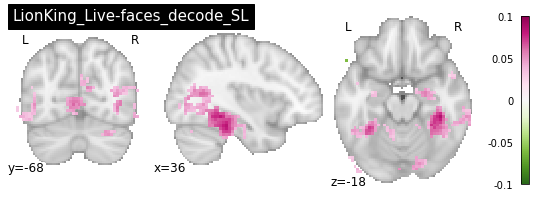

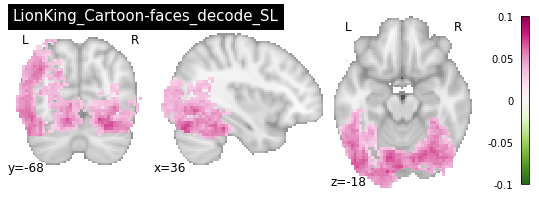

In [34]:
# Now, plot the whole brain results, which were created using the Python script Feature_Decoding_Searchlight.py
analysis='faces_decode_SL' # name of the analysis 
thr_type='tfce_corrp_tstat1' # corrected results
chance=0.5 # reminder of the chance level for this analysis 

# cycle through movies 
for movie in ['LionKing_Live','LionKing_Cartoon']:

    # load the corrected file
    infant_mvpa_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_infants_%s.nii.gz'%
                               (movie,analysis,thr_type))

    # create the average MVPA classification accuracy map from the searchlight outputs
    infant_mvpa_files = np.sort(np.hstack((glob.glob(base_dir+'data/Movies/%s/%s/s*_decode_movie.nii.gz' % (movie,analysis)),
                                               glob.glob(base_dir+'data/Movies/%s/%s/LM*_decode_movie.nii.gz' % (movie,analysis)))))
    # average them 
    infant_mvpa_uncorr = mean_img(infant_mvpa_files) 

    # (subtract off the chance value to get a better color range of values for plotting purposes)
    infant_mvpa_thresholded = infant_mvpa_uncorr.get_fdata()- chance
    
    # then, threshold it by the corrected file 
    infant_mvpa_thresholded[infant_mvpa_corr.get_fdata()<0.95]=0

    # turn it into a nifti
    infant_mvpa_tstat_map = nib.Nifti1Image(infant_mvpa_thresholded,infant_mvpa_uncorr.affine)

    # plot ! 
    fig = plotting.plot_stat_map(infant_mvpa_tstat_map,
                                 cmap='PiYG_r',vmax=0.1,
                                 title='%s-%s' % (movie,analysis),
                           cut_coords=(36,-68,-18),draw_cross=False)
    
    fig.savefig(save_plot_dir+'/infant_%s_%s_%s.svg'% (analysis,movie.split('LionKing_')[-1].lower(),thr_type))

2.796939504772804


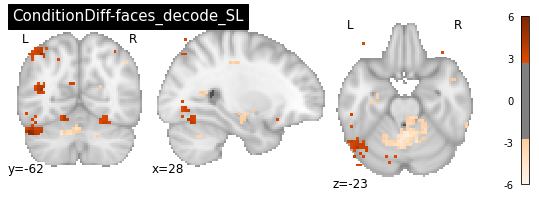

In [35]:
# Next, load in the results for the DIFFERENCE between movies 
# after having run FSL randomise (on the command line, see README)
# tstat1 = live > cartoon, tstat2 = cartoon > live 
analysis='faces_decode_SL' # reminder, this is the face decoding analysis 
thr_type='tstat2' # uncorrected map

# change the threshold / color if we are using a corrected 1-p value map 
if 'corrp' not in thr_type:

    # load the file 
    infant_isc_diff_stat_map = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz'%
                                        (analysis,thr_type))


    thresh=stats.t.ppf(0.995, len(df.ppt)) 
    print(thresh)
else:
    # load the corrected file
    infant_isc_diff_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz' %
                               (analysis,thr_type))

    # load the uncorrected file 
    infant_isc_diff_uncorr = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz' %
                                 (analysis,thr_type.split('corrp_')[-1]))

    # threshold it by the corrected file 
    infant_isc_diff_thresholded = infant_isc_diff_uncorr.get_fdata()
    infant_isc_diff_thresholded[infant_isc_diff_corr.get_fdata()<0.95]=0

    # turn it into a nifti
    infant_isc_diff_stat_map = nib.Nifti1Image(infant_isc_diff_thresholded,infant_isc_diff_uncorr.affine)

    thresh=np.min(infant_isc_diff_thresholded[np.nonzero(infant_isc_diff_thresholded)])
    print(thresh)

fig = plotting.plot_stat_map(infant_isc_diff_stat_map,threshold=thresh,
                             cmap='Oranges',vmax=6,
                             title='ConditionDiff-%s' % (analysis),cut_coords=(28,-62,-23), 
                       draw_cross=False)

fig.savefig(save_plot_dir+'/infant_%s_condition_diff_%s.svg'% (analysis,thr_type))

### Scenes 
Can we decode the spatial distance of a scene?

Live -- Scene distance?
Close-up 31
Far 28
Medium 31

Cartoon -- Scene distance?
Close-up 29
Far 26
Medium 35



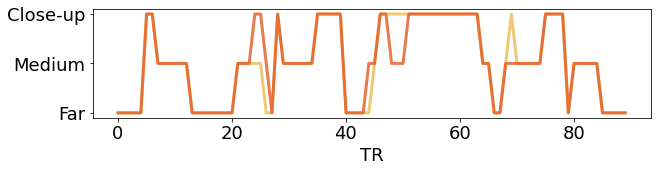

In [23]:
# Plot the regressor for scenes 
scene_regressor_dict=dict({'Far':0,'Medium':1,'Close-up':2})

fig = plt.figure(figsize=(10,2))
plt.plot([scene_regressor_dict[i] for i in np.array(list(cartoonlive_regressors['Scene - %s' % 'Live']))],color=palette[0],linewidth=3,alpha=0.8)
plt.plot([scene_regressor_dict[i] for i in np.array(list(cartoonlive_regressors['Scene - %s' % 'Cartoon']))],color=palette[1],linewidth=3,alpha=0.8)
plt.yticks(fontsize=16)
plt.yticks([0,1,2],scene_regressor_dict,fontsize=18)
plt.xticks(fontsize=18)
plt.xlabel('TR',fontsize=18)

fig.savefig(save_plot_dir+'scene_timecourse.svg')

# Cycle through the movies and report the number of examples of each condition
for movie in ['Live','Cartoon']:
    print(movie,'-- Scene distance?')

    # what regressor are we using? 
    regressor = np.array(list(cartoonlive_regressors['Scene - %s' % movie]))
    for unique in np.unique(regressor):
        print(unique,sum(regressor==unique))
        
    print()

VO_combined
Classification of scenes during Live: 0.358, CIs = [0.334 to 0.383], pval = 0.028
Classification of scenes during Cartoon: 0.389, CIs = [0.370 to 0.407], pval = 0.000
Difference: -0.031, CIs = [-0.057 to -0.006], pval = 0.014
Infants corr with age live: r=-0.043, p=0.814
Infants corr with age cartoon: r=-0.202,  p=0.322

bilateral_FFA
Classification of scenes during Live: 0.349, CIs = [0.324 to 0.377], pval = 0.154
Classification of scenes during Cartoon: 0.351, CIs = [0.324 to 0.377], pval = 0.122
Difference: -0.002, CIs = [-0.031 to 0.031], pval = 0.900
Infants corr with age live: r=0.095, p=0.756
Infants corr with age cartoon: r=0.117,  p=0.674

bilateral_PPA
Classification of scenes during Live: 0.357, CIs = [0.330 to 0.389], pval = 0.046
Classification of scenes during Cartoon: 0.369, CIs = [0.339 to 0.396], pval = 0.010
Difference: -0.011, CIs = [-0.054 to 0.037], pval = 0.644
Infants corr with age live: r=-0.268, p=0.120
Infants corr with age cartoon: r=0.024,  p=0.8

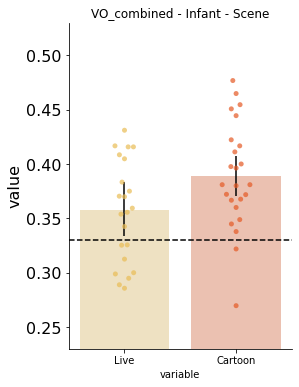

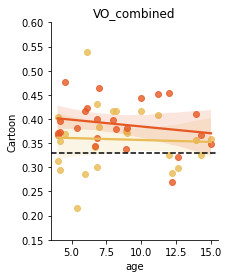

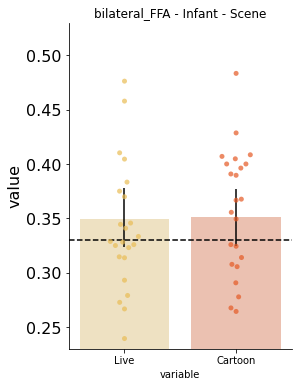

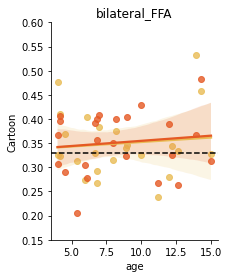

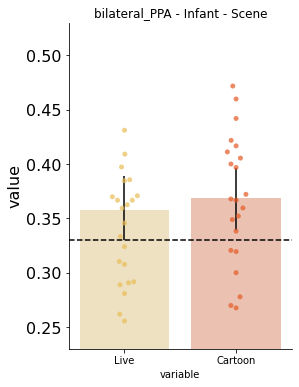

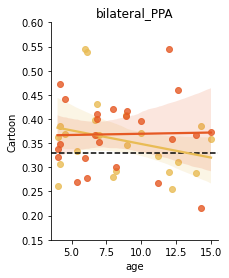

In [29]:
# Preset a LOO for the cross-validation
loo=LeaveOneOut()

# set a random seed
np.random.seed(0)

# Cycle through the ROIs 
for roi in ['VO_combined','bilateral_FFA','bilateral_PPA']:
    
    print(roi)

    # Load in the standard ROI mask (in 3mm space)
    roi_nii=nib.load(base_dir+'data/CartoonLive/ROIs/'+roi+'.nii.gz')
    
    # get the ROI values by using the brain masker on the ROI
    roi_vals = brain_masker.fit_transform(roi_nii)[0]

    # only get the values for this ROI for the infant data
    infant_live_roi = live_stacked_data[:,:,roi_vals==1]
    infant_cartoon_roi = cartoon_stacked_data[:,:,roi_vals==1]

    # preset a dictionary for the decoding results
    decoding_dict_closeup = dict()

    # Cycle through the movies 
    for movie in ['Live','Cartoon']:
        
        # which regressor are we using? 
        regressor = np.array(list(cartoonlive_regressors['Scene - %s' % movie]))

        # get the data according to which movie 
        if movie == 'Live':
            data_roi = infant_live_roi
        else:
            data_roi = infant_cartoon_roi

        # preset
        decoding_accuracy = []
        sub_ages = []

        # For each possible subject
        for _, sub in loo.split(data_roi):

            # Get the average pattern of activity for this infant for the two movies 
            sub_close_pattern = data_roi[sub[0]][regressor=='Close-up']
            sub_med_pattern = data_roi[sub[0]][regressor=='Medium']
            sub_far_pattern = data_roi[sub[0]][regressor=='Far']

            # Get the average pattern of activity for all OTHER infant for the two movies 
            average_close_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='Close-up'],axis=0)
            average_med_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='Medium'],axis=0)
            average_far_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='Far'],axis=0)

            sub_decoding = mvpa_trial_decoding_3way_avg(sub_close_pattern,average_close_pattern,
                                              sub_med_pattern,average_med_pattern,
                                                  sub_far_pattern,average_far_pattern)
            # append the subject level decoding
            decoding_accuracy.append(sub_decoding)
            
            # add the age as well 
            # (only works because the infant_live_roi and infant_cartoon_roi arrays are in the same order as the dictionary)
            sub_ages.append(list(df.age[df.ppt==list(cartoon_data.keys())[sub[0]]])[0])

        # append to dictionary
        decoding_dict_closeup[movie]=decoding_accuracy


    # preset a plot
    fig,ax = plt.subplots(figsize=(4,6))
    plt.title('%s - Infant - Scene' %(roi))
    plt.ylim(0,1)
    plt.axhline(0.33,linestyle='--',color='k')
    plt.ylabel('classification accuracy',fontsize=16)
    plt.yticks(fontsize=16)

    # Plot the results
    sns.barplot(x='variable',y='value',data=pd.DataFrame(decoding_dict_closeup).melt(),palette=palette,alpha=0.4,
                order=['Live','Cartoon'],ci=None)
    sns.swarmplot(x='variable',y='value',data=pd.DataFrame(decoding_dict_closeup).melt(),palette=palette,alpha=0.7,
                order=['Live','Cartoon'])
    plt.ylim(0.23,0.53)

    # report the statistics
    for m, movie in enumerate(['Live','Cartoon']):
        pval, CIs=bootstrap_mean(decoding_dict_closeup[movie],null_vall=0.33)

        print('Classification of scenes during %s: %0.3f, CIs = [%0.3f to %0.3f], pval = %0.3f' %
              (movie,np.nanmean(decoding_dict_closeup[movie]),CIs[0],CIs[1],pval))

        plt.errorbar(m,np.nanmean(decoding_dict_closeup[movie]),
                 yerr=(np.abs(np.nanmean(decoding_dict_closeup[movie])-np.array(CIs))).reshape(-1,1),
                     fmt='none',ecolor='k') #use our CI

    pval,CIs =bootstrap_mean(np.array(decoding_dict_closeup['Live'])-np.array(decoding_dict_closeup['Cartoon']),null_vall=0)
    print('Difference: %0.3f, CIs = [%0.3f to %0.3f], pval = %0.3f' %(np.mean(np.array(decoding_dict_closeup['Live'])-np.array(decoding_dict_closeup['Cartoon'])),
                                                                      CIs[0],CIs[1],pval))

    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # save plot
    fig.savefig(save_plot_dir+'/infants_%s_scene_decoding.svg' % (roi))

    ####### Infant age effects 
    # Within the two conditions 
    temp_df_decoding = pd.DataFrame(decoding_dict_closeup)
    temp_df_decoding['age']=sub_ages # add age to the dataframe

    fig, ax=plt.subplots(1,1,figsize=(3,4),sharey=True)
    plt.title(roi)
    plt.xlim(3.5,15.5)
    plt.ylim(0.15,0.6)
    plt.ylabel('mvpa scenes')
    plt.axhline(0.33,linestyle='--',color='k')
    
    # plot the data
    sns.regplot(x='age',y='Live',data=temp_df_decoding,color=palette[0],label='live')
    sns.regplot(x='age',y='Cartoon',data=temp_df_decoding,color=palette[1],label='cartoon')
    
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # report the stats
    p, CIs=bootstrap_corr(np.array(temp_df_decoding['age']),np.array(temp_df_decoding['Live']),nPerm=1000)
    print('Infants corr with age live: r=%0.3f, p=%0.3f' %(stats.pearsonr(np.array(temp_df_decoding['age']),np.array(temp_df_decoding['Live']))[0],p))

    p, CIs=bootstrap_corr(np.array(temp_df_decoding['age']),np.array(temp_df_decoding['Cartoon']),nPerm=1000)
    print('Infants corr with age cartoon: r=%0.3f,  p=%0.3f' %(stats.pearsonr(np.array(temp_df_decoding['age']),np.array(temp_df_decoding['Cartoon']))[0],p))

    fig.savefig('%s/infants_age_%s_scene_decoding.svg' %(save_plot_dir,roi))

    print()

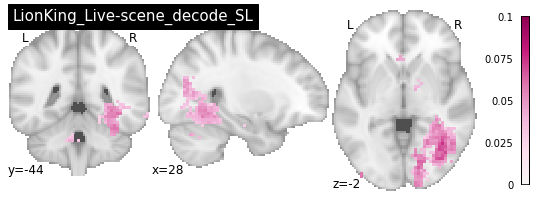

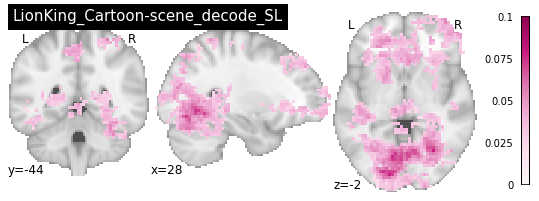

In [20]:
# Now, plot the whole brain results, which were created using the Python script Feature_Decoding_Searchlight.py
analysis='scene_decode_SL' # name of the analysis 
thr_type='tfce_corrp_tstat1' # corrected results
chance=0.33 # reminder of the chance level for this analysis 

# cylce through movies 
for movie in ['LionKing_Live','LionKing_Cartoon']:
    
    # load the corrected file
    infant_mvpa_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_infants_%s.nii.gz'%
                               (movie,analysis,thr_type))

    # actually, create the average MVPA classification accuracy map 
    # get all the files 
    infant_mvpa_files = np.sort(np.hstack((glob.glob(base_dir+'data/Movies/%s/%s/s*_decode_movie.nii.gz' % (movie,analysis)),
                                               glob.glob(base_dir+'data/Movies/%s/%s/LM*_decode_movie.nii.gz' % (movie,analysis)))))

    # average them 
    infant_mvpa_uncorr = mean_img(infant_mvpa_files)

    # (subtract off the chance value to get a better color range of values for plotting purposes)
    infant_mvpa_thresholded = infant_mvpa_uncorr.get_fdata()-chance
    
    # threshold it by the corrected file 
    infant_mvpa_thresholded[infant_mvpa_corr.get_fdata()<0.95]=0

    # turn it into a nifti
    infant_mvpa_tstat_map = nib.Nifti1Image(infant_mvpa_thresholded,infant_mvpa_uncorr.affine)
        
    fig = plotting.plot_stat_map(infant_mvpa_tstat_map,
                                 cmap='PiYG_r',vmax=0.1,
                                 title='%s-%s' % (movie,analysis),
                           cut_coords=(28,-44,-2),draw_cross=False)
    
    fig.savefig(save_plot_dir+'/infant_%s_%s_%s.svg'% (analysis,movie.split('LionKing_')[-1].lower(),thr_type))

2.796939504772804


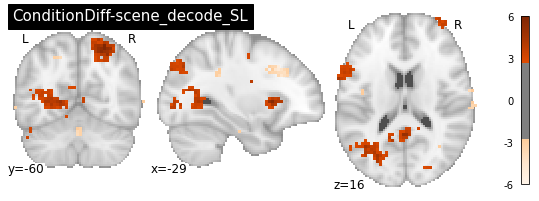

In [25]:
# Next, load in the results for the DIFFERENCE between movies 
# after having run FSL randomise (on the command line, see README)
# tstat1 = live > cartoon, tstat2 = cartoon > live 
analysis='scene_decode_SL' # reminder, this is the face decoding analysis 
thr_type='tstat2' # uncorrected map

# change the threshold / color if we are using a corrected 1-p value map 
if 'corrp' not in thr_type:

    # load the file 
    infant_isc_diff_stat_map = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz'%
                                        (analysis,thr_type))


    thresh=stats.t.ppf(0.995, len(df.ppt)) 
    print(thresh)
else:
    # load the corrected file
    infant_isc_diff_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz' %
                               (analysis,thr_type))

    # load the uncorrected file 
    infant_isc_diff_uncorr = nib.load(base_dir+'data/CartoonLive/randomise/%s_infants_condition_diff_%s.nii.gz' %
                                 (analysis,thr_type.split('corrp_')[-1]))

    # threshold it by the corrected file 
    infant_isc_diff_thresholded = infant_isc_diff_uncorr.get_fdata()
    infant_isc_diff_thresholded[infant_isc_diff_corr.get_fdata()<0.95]=0

    # turn it into a nifti
    infant_isc_diff_stat_map = nib.Nifti1Image(infant_isc_diff_thresholded,infant_isc_diff_uncorr.affine)

    thresh=np.min(infant_isc_diff_thresholded[np.nonzero(infant_isc_diff_thresholded)])
    print(thresh)

fig = plotting.plot_stat_map(infant_isc_diff_stat_map,threshold=thresh,
                             cmap='Oranges',vmax=6,
                             title='ConditionDiff-%s' % (analysis),cut_coords=(-29,-60,16),
                       draw_cross=False)

fig.savefig(save_plot_dir+'/infant_%s_condition_diff_%s.svg'% (analysis,thr_type))

### Face and scene decoding for adults 
Same analyses as above, now with the adult participants

VO_combined
Classification of faces during Live: 0.679, CIs = [0.659 to 0.701], pval = 0.000
Classification of faces during Cartoon: 0.678, CIs = [0.653 to 0.701], pval = 0.000
Difference: 0.002, CIs = [-0.022 to 0.025], pval = 0.862

bilateral_FFA
Classification of faces during Live: 0.628, CIs = [0.593 to 0.661], pval = 0.000
Classification of faces during Cartoon: 0.652, CIs = [0.623 to 0.682], pval = 0.000
Difference: -0.024, CIs = [-0.058 to 0.010], pval = 0.174

bilateral_PPA
Classification of faces during Live: 0.635, CIs = [0.601 to 0.666], pval = 0.000
Classification of faces during Cartoon: 0.606, CIs = [0.559 to 0.651], pval = 0.000
Difference: 0.029, CIs = [-0.002 to 0.061], pval = 0.076



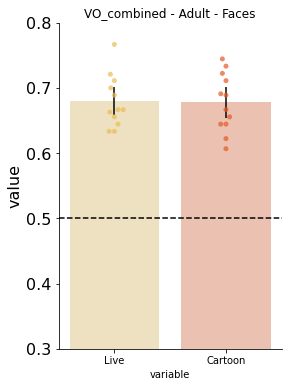

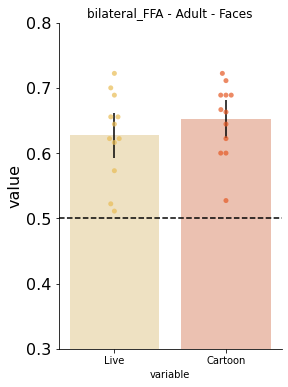

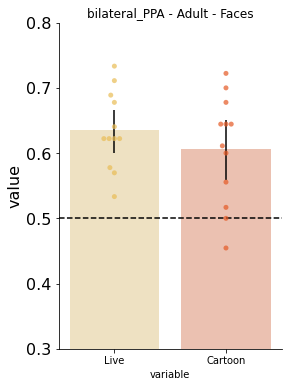

In [28]:
# Preset a LOO for the cross-validation
loo=LeaveOneOut()

# set a random seed
np.random.seed(0)

# Cycle through the ROIs 
for roi in ['VO_combined','bilateral_FFA','bilateral_PPA']:
    
    print(roi)

    # Load in the standard ROI mask (in 3mm space)
    roi_nii=nib.load(base_dir+'data/CartoonLive/ROIs/'+roi+'.nii.gz')
    
    # get the ROI values by using the brain masker on the ROI
    roi_vals = brain_masker.fit_transform(roi_nii)[0]

    # only get the values for this ROI for the infant data
    adult_live_roi = adult_live_stacked_data[:,:,roi_vals==1]
    adult_cartoon_roi = adult_cartoon_stacked_data[:,:,roi_vals==1]

    # preset a dictionary for the decoding results
    decoding_dict = dict()

    # Cycle through the movies 
    for movie in ['Live','Cartoon']:
        
        # which regressor are we using? 
        regressor = np.array(list(cartoonlive_regressors['Faces - %s' % movie]))

        # get the data according to which movie 
        if movie == 'Live':
            data_roi = adult_live_roi
        else:
            data_roi = adult_cartoon_roi

        # preset
        decoding_accuracy = []

        # For each possible subject
        for _, sub in loo.split(data_roi):

            # Get the average pattern of activity for this infant for the two conditions
            sub_face_pattern = data_roi[sub[0]][regressor=='Yes']
            sub_no_face_pattern = data_roi[sub[0]][regressor=='No']

            # Get the average pattern of activity for all OTHER infants for the two conditions
            average_face_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='Yes'],axis=0)
            average_no_face_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='No'],axis=0)

            # Run the MVPA trial decoding 
            sub_decoding = mvpa_trial_decoding_avg(sub_face_pattern,average_face_pattern,
                                              sub_no_face_pattern,average_no_face_pattern,)

            # add subjects' decoding value to the list
            decoding_accuracy.append(sub_decoding)

        # add all of this to the dictionary 
        decoding_dict[movie]=decoding_accuracy
        
    # preset a plot
    fig,ax = plt.subplots(figsize=(4,6))
    
    # plot the results 
    plt.title('%s - Adult - Faces' %(roi))
    plt.ylim(0,1)
    plt.axhline(0.5,linestyle='--',color='k')
    plt.ylabel('classification accuracy',fontsize=16)
    plt.yticks(fontsize=16)
    
    # Plot the results
    sns.barplot(x='variable',y='value',data=pd.DataFrame(decoding_dict).melt(),palette=palette,alpha=0.4,
                order=['Live','Cartoon'],ci=None)
    sns.swarmplot(x='variable',y='value',data=pd.DataFrame(decoding_dict).melt(),palette=palette,alpha=0.7,
                order=['Live','Cartoon'])
    plt.ylim(0.3,0.8)

    # report the statistics as well 
    for m, movie in enumerate(['Live','Cartoon']):
        pval, CIs=bootstrap_mean(decoding_dict[movie],null_vall=0.5)

        print('Classification of faces during %s: %0.3f, CIs = [%0.3f to %0.3f], pval = %0.3f' %
              (movie,np.nanmean(decoding_dict[movie]),CIs[0],CIs[1],pval))

        plt.errorbar(m,np.nanmean(decoding_dict[movie]),
                 yerr=(np.abs(np.nanmean(decoding_dict[movie])-np.array(CIs))).reshape(-1,1),
                     fmt='none',ecolor='k') #use our CI

    pval,CIs =bootstrap_mean(np.array(decoding_dict['Live'])-np.array(decoding_dict['Cartoon']),null_vall=0)
    print('Difference: %0.3f, CIs = [%0.3f to %0.3f], pval = %0.3f' %(np.mean(np.array(decoding_dict['Live'])-np.array(decoding_dict['Cartoon'])),
                                                                      CIs[0],CIs[1],pval))

    plt.ylim(0.3,0.8)

    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # save the plot 
    fig.savefig(save_plot_dir+'/adults_%s_face_decoding.svg' % (roi))

    print()

12
12


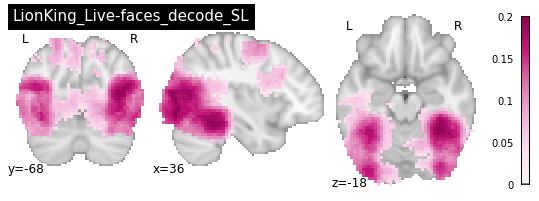

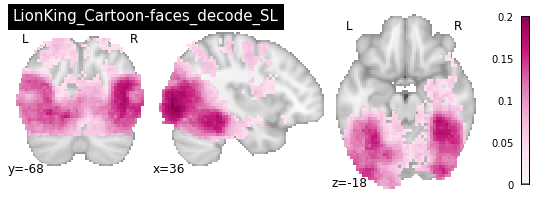

In [31]:
analysis='faces_decode_SL'
thr_type='tfce_corrp_tstat1'
chance=0.5

for movie in ['LionKing_Live','LionKing_Cartoon']:
    
    # change the threshold / color if we are using a corrected 1-p value map 
    if 'corrp' not in thr_type:
        
        # load the file 
        adult_mvpa_tstat_map = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_adults_%s.nii.gz'%
                                   (movie,analysis,thr_type))
    
        thresh=stats.t.ppf(0.995, len(adult_df.ppt)) # remember, use the adults here
    else:
        # load the corrected file
        adult_mvpa_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_adults_%s.nii.gz'%
                                   (movie,analysis,thr_type))
              
        # actually, create the average MVPA classification accuracy map 
        # get all the files 
        adult_mvpa_files = np.sort(glob.glob(base_dir+'data/Movies/%s/%s/rest_movie*_decode_movie.nii.gz' % (movie,analysis)))
        print(len(adult_mvpa_files))

        # average them 
        adult_mvpa_uncorr = mean_img(adult_mvpa_files) 

        # threshold it by the corrected file 
        # (subtract off the chance value to get a better color range of values for plotting purposes)
        adult_mvpa_thresholded = adult_mvpa_uncorr.get_fdata()- chance
        adult_mvpa_thresholded[adult_mvpa_corr.get_fdata()<0.95]=0
        
        # then only get the positive values (for plotting purposes)
        adult_mvpa_thresholded[adult_mvpa_thresholded<0]=0
        
        # turn it into a nifti
        adult_mvpa_tstat_map = nib.Nifti1Image(adult_mvpa_thresholded,adult_mvpa_uncorr.affine)
        
    
    fig = plotting.plot_stat_map(adult_mvpa_tstat_map,threshold=0.004,
                                 cmap='PiYG_r',vmax=0.2,
                                 title='%s-%s' % (movie,analysis),
                           cut_coords=(36,-68,-18),draw_cross=False)
    
    fig.savefig(save_plot_dir+'/adult_%s_%s_%s.svg'% (analysis,movie.split('LionKing_')[-1].lower(),thr_type))

VO_combined
Classification of scenes during Live: 0.509, CIs = [0.481 to 0.542], pval = 0.000
Classification of scenes during Cartoon: 0.473, CIs = [0.442 to 0.504], pval = 0.000
Difference: 0.036, CIs = [0.004 to 0.069], pval = 0.034

bilateral_FFA
Classification of scenes during Live: 0.422, CIs = [0.400 to 0.446], pval = 0.000
Classification of scenes during Cartoon: 0.425, CIs = [0.396 to 0.456], pval = 0.000
Difference: -0.003, CIs = [-0.032 to 0.028], pval = 0.850

bilateral_PPA
Classification of scenes during Live: 0.457, CIs = [0.429 to 0.485], pval = 0.000
Classification of scenes during Cartoon: 0.410, CIs = [0.371 to 0.451], pval = 0.000
Difference: 0.047, CIs = [0.004 to 0.084], pval = 0.038



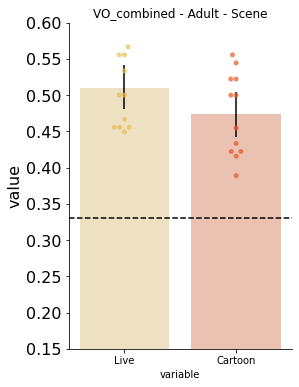

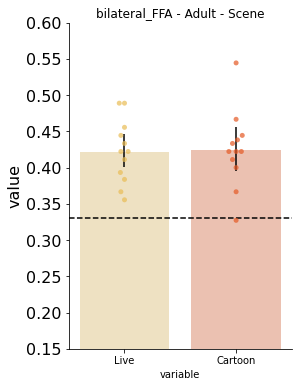

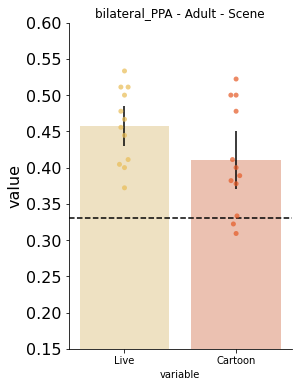

In [29]:
# Preset a LOO for the cross-validation
loo=LeaveOneOut()

# set a random seed
np.random.seed(0)

# Cycle through the ROIs 
for roi in ['VO_combined','bilateral_FFA','bilateral_PPA']:
    
    print(roi)

    # Load in the standard ROI mask (in 3mm space)
    roi_nii=nib.load(base_dir+'data/CartoonLive/ROIs/'+roi+'.nii.gz')
    
    # get the ROI values by using the brain masker on the ROI
    roi_vals = brain_masker.transform(roi_nii)[0]

    # only get the values for this ROI for the infant data
    adult_live_roi = adult_live_stacked_data[:,:,roi_vals==1]
    adult_cartoon_roi = adult_cartoon_stacked_data[:,:,roi_vals==1]

    # preset a dictionary for the decoding results
    decoding_dict_closeup = dict()

    # Cycle through the movies 
    for movie in ['Live','Cartoon']:
        
        # which regressor are we using? 
        regressor = np.array(list(cartoonlive_regressors['Scene - %s' % movie]))

        # get the data according to which movie 
        if movie == 'Live':
            data_roi = adult_live_roi
        else:
            data_roi = adult_cartoon_roi

        # preset
        decoding_accuracy = []

        # For each possible subject
        for _, sub in loo.split(data_roi):

            # Get the average pattern of activity for this *adult* for the two movies 
            sub_close_pattern = data_roi[sub[0]][regressor=='Close-up']
            sub_med_pattern = data_roi[sub[0]][regressor=='Medium']
            sub_far_pattern = data_roi[sub[0]][regressor=='Far']

            # Get the average pattern of activity for all OTHER *adults* for the two movies 
            average_close_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='Close-up'],axis=0)
            average_med_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='Medium'],axis=0)
            average_far_pattern = np.nanmean(np.delete(data_roi,sub[0],axis=0)[:,regressor=='Far'],axis=0)

            sub_decoding = mvpa_trial_decoding_3way_avg(sub_close_pattern,average_close_pattern,
                                              sub_med_pattern,average_med_pattern,
                                                  sub_far_pattern,average_far_pattern)
            # append the subject level decoding
            decoding_accuracy.append(sub_decoding)

        # append to dictionary
        decoding_dict_closeup[movie]=decoding_accuracy


    # preset a plot
    fig,ax = plt.subplots(figsize=(4,6))
    plt.title('%s - Adult - Scene' %(roi))
    plt.ylim(0,1)
    plt.axhline(0.33,linestyle='--',color='k')
    plt.ylabel('classification accuracy',fontsize=16)
    plt.yticks(fontsize=16)

    # Plot the results
    sns.barplot(x='variable',y='value',data=pd.DataFrame(decoding_dict_closeup).melt(),palette=palette,alpha=0.4,
                order=['Live','Cartoon'],ci=None)
    sns.swarmplot(x='variable',y='value',data=pd.DataFrame(decoding_dict_closeup).melt(),palette=palette,alpha=0.7,
                order=['Live','Cartoon'])
    plt.ylim(0.15,0.6)

    # report the statistics
    for m, movie in enumerate(['Live','Cartoon']):
        pval, CIs=bootstrap_mean(decoding_dict_closeup[movie],null_vall=0.33)

        print('Classification of scenes during %s: %0.3f, CIs = [%0.3f to %0.3f], pval = %0.3f' %
              (movie,np.nanmean(decoding_dict_closeup[movie]),CIs[0],CIs[1],pval))

        plt.errorbar(m,np.nanmean(decoding_dict_closeup[movie]),
                 yerr=(np.abs(np.nanmean(decoding_dict_closeup[movie])-np.array(CIs))).reshape(-1,1),
                     fmt='none',ecolor='k') #use our CI

    pval,CIs =bootstrap_mean(np.array(decoding_dict_closeup['Live'])-np.array(decoding_dict_closeup['Cartoon']),null_vall=0)
    print('Difference: %0.3f, CIs = [%0.3f to %0.3f], pval = %0.3f' %(np.mean(np.array(decoding_dict_closeup['Live'])-np.array(decoding_dict_closeup['Cartoon'])),
                                                                      CIs[0],CIs[1],pval))

    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # save plot
    fig.savefig(save_plot_dir+'/adults_%s_scene_decoding.svg' % (roi))

    print()

12
12


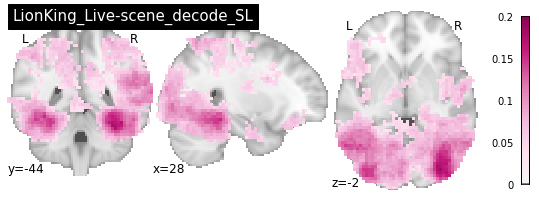

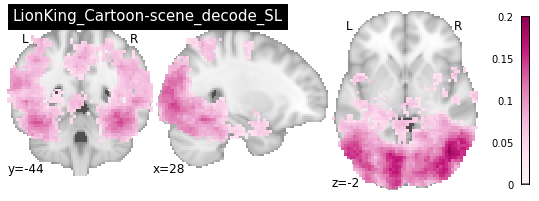

In [33]:
analysis='scene_decode_SL'
thr_type='tfce_corrp_tstat1'
chance=0.33

for movie in ['LionKing_Live','LionKing_Cartoon']:
    
    # change the threshold / color if we are using a corrected 1-p value map 
    if 'corrp' not in thr_type:
        
        # load the file 
        adult_mvpa_tstat_map = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_adults_%s.nii.gz'%
                                   (movie,analysis,thr_type))
    
        thresh=stats.t.ppf(0.995, len(adult_df.ppt)) # remember, use the adults here 
    else:
        # load the corrected file
        adult_mvpa_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_adults_%s.nii.gz'%
                                   (movie,analysis,thr_type))
              
        # actually, create the average MVPA classification accuracy map 
        # get all the files 
        adult_mvpa_files = np.sort(glob.glob(base_dir+'data/Movies/%s/%s/rest_movie*_decode_movie.nii.gz' % (movie,analysis)))
        print(len(adult_mvpa_files))

        # average them 
        adult_mvpa_uncorr = mean_img(adult_mvpa_files) 

        # threshold it by the corrected file 
        # (subtract off the chance value to get a better color range of values for plotting purposes)
        adult_mvpa_thresholded = adult_mvpa_uncorr.get_fdata()- chance
        adult_mvpa_thresholded[adult_mvpa_corr.get_fdata()<0.95]=0
        
        # then only get the positive values (for plotting purposes)
        adult_mvpa_thresholded[adult_mvpa_thresholded<0]=0
        
        # turn it into a nifti
        adult_mvpa_tstat_map = nib.Nifti1Image(adult_mvpa_thresholded,adult_mvpa_uncorr.affine)
        
    fig = plotting.plot_stat_map(adult_mvpa_tstat_map,threshold=0.004,
                                 cmap='PiYG_r',vmax=0.2,
                                 title='%s-%s' % (movie,analysis),
                           cut_coords=(28,-44,-2),draw_cross=False)
    
    fig.savefig(save_plot_dir+'/adult_%s_%s_%s.svg'% (analysis,movie.split('LionKing_')[-1].lower(),thr_type))

## Supplementary analyses <a id='supp'></a> 

### EyeSC
Spatial intersubject correlation in eyeball ROIs to look at whether gaze behavior may differ between the two movies.

Number of voxels in the eyeball ROI: 1032.0


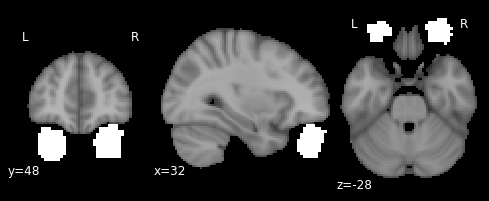

In [30]:
# load in the mask for the eyeballs and view it
eye_nii=nib.load(base_dir+'data/CartoonLive/ROIs/intersect_mask_standard_eyes.nii.gz') 
eye_masker=NiftiMasker(mask_img=eye_nii)

# fit the brain masker
test_sub=eye_nii
test_fit=eye_masker.fit(test_sub)
affine_mat = test_sub.affine
dimsize = test_sub.header.get_zooms()
coords= np.where(eye_nii.get_fdata())

# plot it! (but on a different background)
fig = plotting.plot_stat_map(eye_nii,bg_img=datasets.load_mni152_template(),
                 draw_cross=False,cut_coords=(32,48,-28),colorbar=False)

print('Number of voxels in the eyeball ROI:', np.sum(eye_nii.get_fdata()))

# save this 
fig.savefig('%s/eyeball_intersect.svg' %(save_plot_dir))

In [31]:
# Where do the functional data for the eyeballs exist?
# NOTE we did not smooth the eyeball data to reduce influence from nearby brain voxels
live_data_eyes_funcs=live_data_folder+'smoothing0_sfnrmask-1/preprocessed_standard/nonlinear_alignment/'
cartoon_data_eyes_funcs=cartoon_data_folder+'smoothing0_sfnrmask-1//preprocessed_standard/nonlinear_alignment/'

In [32]:
# preset
live_data_eyes=dict()
live_files=np.hstack((glob.glob(live_data_eyes_funcs+'s*'),glob.glob(live_data_eyes_funcs+'L*')))

print('LionKing Live')
# cycle through the files and preprocess the data 
for live_file in live_files:
    sub=live_file.split(live_data_eyes_funcs)[1].split('_functional')[0].split('_Z.nii.gz')[0] # find subject name 
    data=preprocess_data_eyes(sub,live_data_folder,eye_nii) # preprocess (remember to use the eye mask)
    data=data[tr_shift:nTRs+tr_shift] # shift the data to align to the movie
    live_data_eyes[sub]=stats.zscore(data,axis=0,nan_policy='omit') # don't forget to z-score over time
    
# preset
cartoon_data_eyes=dict()
cartoon_files=np.hstack((glob.glob(cartoon_data_eyes_funcs+'s*'),glob.glob(cartoon_data_eyes_funcs+'L*')))

print('\nLionKing Cartoon')
# cycle through the files and preprocess the data 
for cartoon_file in cartoon_files:
    sub=cartoon_file.split(cartoon_data_eyes_funcs)[1].split('_functional')[0].split('_Z.nii.gz')[0] # find subject name 
    data=preprocess_data_eyes(sub,cartoon_data_folder,eye_nii) # preprocess (remember to use the eye mask)
    data=data[tr_shift:nTRs+tr_shift] # shift the data to align to the movie 
    cartoon_data_eyes[sub]=stats.zscore(data,axis=0,nan_policy='omit') # don't forget to z-score over time

LionKing Live
s2816_1_1 has 18 % of TRs excluded
s7836_2_1 has 27 % of TRs excluded
s1736_1_2 has 0 % of TRs excluded
s7927_1_1 has 33 % of TRs excluded
s6816_1_1 has 18 % of TRs excluded
s3097_2_1 has 14 % of TRs excluded
s5206_1_1 has 28 % of TRs excluded
s4258_1_2 has 14 % of TRs excluded
s1206_1_2 has 3 % of TRs excluded
s9986_1_4 has 4 % of TRs excluded
s7286_2_2 has 2 % of TRs excluded
s4258_1_1 has 11 % of TRs excluded
s2256_1_1 has 35 % of TRs excluded
s3097_2_3 has 0 % of TRs excluded
s3097_2_2 has 43 % of TRs excluded
s4986_1_1 has 1 % of TRs excluded
s2986_1_3 has 1 % of TRs excluded
s1206_1_1 has 11 % of TRs excluded
s5256_1_1 has 55 % of TRs excluded
s2836_1_2 has 1 % of TRs excluded
LM003_4 has 0 % of TRs excluded
LM003_3 has 21 % of TRs excluded
LM009_3 has 8 % of TRs excluded
LM003_2 has 46 % of TRs excluded

LionKing Cartoon
s2816_1_1 has 3 % of TRs excluded
s7836_2_1 has 42 % of TRs excluded
s1736_1_2 has 1 % of TRs excluded
s7927_1_1 has 21 % of TRs excluded
s6816_1_

In [33]:
# Get them in the same order (works as long as all kids have each video)
live_data_eyes=dict(sorted(live_data_eyes.items()))
cartoon_data_eyes=dict(sorted(cartoon_data_eyes.items()))

# Stack
live_stacked_data_eyes=np.stack([v for v in live_data_eyes.values()])
cartoon_stacked_data_eyes=np.stack([v for v in cartoon_data_eyes.values()])

In [34]:
# Calculate spatial ISC -- same function as above, but transposed 
# We use spatial ISC (rather than temporal) to maintain the fine-grained pattern in the eyeball
spatial_isc_live_eyes=isc(live_stacked_data_eyes.transpose(2,1,0),transpose=True) # vox x TR x sub
spatial_mean_live_eyes=compute_summary_statistic(spatial_isc_live_eyes, summary_statistic='mean', axis=1)

spatial_isc_cartoon_eyes=isc(cartoon_stacked_data_eyes.transpose(2,1,0),transpose=True)  # vox x TR x sub
spatial_mean_cartoon_eyes=compute_summary_statistic(spatial_isc_cartoon_eyes, summary_statistic='mean',axis=1)


Infants spatial ISC in eyeballs live: M = 0.021, CI = [0.011 to 0.032], p=0.000
Infants spatial ISC in eyeballs cartoon: M = 0.020, CI = [0.009 to 0.031], p=0.000
Infants diff in cartoon vs. live: M = 0.001, CI = [-0.014 to 0.017], p=0.880


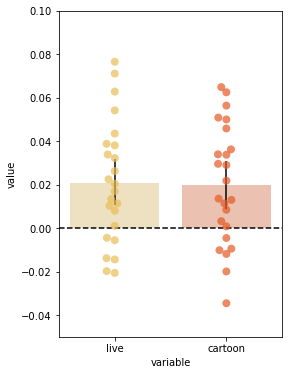

In [35]:
# Now plot and report the statistics
# statistics 
np.random.seed(0)

# make a temporary dataframe for plotting 
temp_df = pd.DataFrame({'live':spatial_mean_live_eyes,'cartoon':spatial_mean_cartoon_eyes})

# preset figure and plot it 
fig,ax = plt.subplots(figsize=(4,6))
sns.barplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.4,ci=None)
sns.swarmplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.7,size=8)
plt.axhline(0,linestyle='dashed',color='k')
plt.xticks([0,1],['live','cartoon'])
plt.ylim(-0.05,0.1)

# report the statistics as well 
for m, movie in enumerate(['live','cartoon']):

    # infants first 
    pval, CIs=bootstrap_mean(temp_df[movie],null_vall=0)

    print('Infants spatial ISC in eyeballs %s: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % (movie,np.nanmean(temp_df[movie]),
                                                                   CIs[0],CIs[1],
                                                                   pval))
    # use our CI, rather than the built in function for plotting
    ax.errorbar(m,np.nanmean(temp_df[movie]),
             yerr=(np.abs(np.nanmean(temp_df[movie])-np.array(CIs))).reshape(-1,1),
                 fmt='none',ecolor='k')

# save plot
fig.savefig('%s/isc_eyeballs.svg' %(save_plot_dir))

# report the movie differences for each 
p_diff, CIs=bootstrap_mean(np.array(temp_df['live']) 
                           - np.array(temp_df['cartoon']),null_vall=0,nPerm=1000)
print('Infants diff in cartoon vs. live: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % 
                                  (np.nanmean(np.array(temp_df['live']) - np.array(temp_df['cartoon'])),
                                                                   CIs[0],CIs[1],
                                                                   p_diff))

In [66]:
## Across movie spatial ISC 
# This allows us to see whether eyeballs have similar patterns across movies (similar gaze patterns?)
all_isc_across_live_sub=[]
all_isc_across_cartoon_sub=[]

for ppt in range(live_stacked_data_eyes.shape[0]):
    
    # with live as the single sub, cartoon as the ref
    sub_data=live_stacked_data_eyes[ppt]
    all_other_data=[val for i,val in enumerate(cartoon_stacked_data_eyes) if i!=ppt]
    stacked_same_ppt=np.dstack((sub_data,np.dstack(all_other_data)))
    isc_across=isc(stacked_same_ppt.transpose(1,0,2),transpose=True)[0] # don't forget to transpose
    
    all_isc_across_live_sub.append(isc_across)
    
    # with cartoon as the single sub, live as the ref
    sub_data=cartoon_stacked_data_eyes[ppt]
    all_other_data=[val for i,val in enumerate(live_stacked_data_eyes) if i!=ppt]
    stacked_same_ppt=np.dstack((sub_data,np.dstack(all_other_data)))
    isc_across=isc(stacked_same_ppt.transpose(1,0,2),transpose=True)[0] # don't forget to transpose
    
    all_isc_across_cartoon_sub.append(isc_across)

Infants spatial ISC in eyeballs across_movies: M = 0.015, CI = [0.006 to 0.023], p=0.000


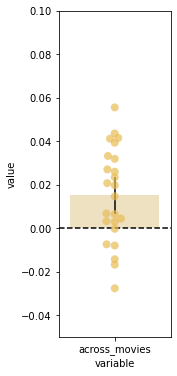

In [79]:
np.random.seed(0)

# get the average ISC for a single subject to all other participants across both comparisons
all_isc_across_both = [(all_isc_across_live_sub[i] + all_isc_across_cartoon_sub[i])/2 for 
                    i in range(len(all_isc_across_live_sub))]
# Average over time
mean_across_both=compute_summary_statistic(all_isc_across_both,axis=1)

# make a temporary dataframe for plotting 
temp_df = pd.DataFrame({'across_movies':mean_across_both})

# preset figure and plot it 
fig,ax = plt.subplots(figsize=(2,6))
sns.barplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.4,ci=None)
sns.swarmplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.7,size=8)
plt.axhline(0,linestyle='dashed',color='k')
plt.xticks([0],['across_movies'])
plt.ylim(-0.05,0.1)

# report the statistics as well 
for m, movie in enumerate(['across_movies']):

    # infants first 
    pval, CIs=bootstrap_mean(temp_df[movie],null_vall=0)

    print('Infants spatial ISC in eyeballs %s: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % (movie,np.nanmean(temp_df[movie]),
                                                                   CIs[0],CIs[1],
                                                                   pval))
    # use our CI, rather than the built in function 
    ax.errorbar(m,np.nanmean(temp_df[movie]),
             yerr=(np.abs(np.nanmean(temp_df[movie])-np.array(CIs))).reshape(-1,1),
                 fmt='none',ecolor='k')

# save plot
fig.savefig('%s/isc_eyeballs_across.svg' %(save_plot_dir))


### Color match analysis 
What does ISC look like in the early visual cortex during a window matched in color complexity? 

Infants live: M = 0.056, CI = [-0.011 to 0.121], p=0.094
Adults live: M = 0.459, CI = [0.377 to 0.538], p=0.000
Infants cartoon: M = 0.121, CI = [0.048 to 0.187], p=0.002
Adults cartoon: M = 0.417, CI = [0.293 to 0.524], p=0.000

Infants diff in cartoon vs. live: M = -0.067, CI = [-0.173 to 0.042], p=0.272
Adults diff in cartoon vs. live: M = 0.042, CI = [-0.056 to 0.149], p=0.422


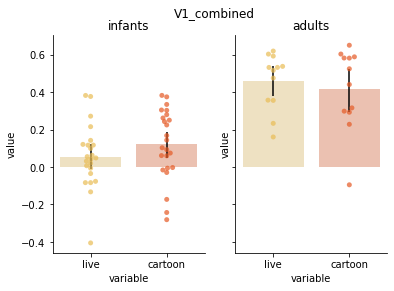

In [50]:
# At what window should the ISC analysis start and stop ? 
# This window is discovered by interrogating the color complexity values in the movie 
# see the notebook CartoonLive_VisualFeatures_Complexity.ipynb
start_idx=65
stop_idx=90

# Which ROI will we consider? 
roi='V1_combined'

# Load in the standard ROI mask (in 3mm space)
roi_nii=nib.load(base_dir+'data/CartoonLive/ROIs/'+roi+'.nii.gz')

# get the ROI values by using the brain masker on the ROI
roi_vals = brain_masker.transform(roi_nii)[0]

# only get the values for this ROI for the infant data, and in the window we defined 
infant_live_roi = live_stacked_data[:,start_idx:stop_idx,roi_vals==1]
infant_cartoon_roi = cartoon_stacked_data[:,start_idx:stop_idx,roi_vals==1]

# only get the values for this ROI for the adult data, and in the window we defined 
adult_live_roi = adult_live_stacked_data[:,start_idx:stop_idx,roi_vals==1]
adult_cartoon_roi = adult_cartoon_stacked_data[:,start_idx:stop_idx,roi_vals==1]

####### Analysis
np.random.seed(0)

# run ISC on infants
isc_live_color_match=isc(infant_live_roi.transpose(1,2,0)) # TR x vox x sub
isc_cartoon_color_match=isc(infant_cartoon_roi.transpose(1,2,0)) # TR x vox x sub

# run ISC on adults
adult_isc_live_color_match=isc(adult_live_roi.transpose(1,2,0)) # TR x vox x sub
adult_isc_cartoon_color_match=isc(adult_cartoon_roi.transpose(1,2,0)) # TR x vox x sub

# create data frames for the average ISC in these rois (don't forget to fisher-Z)
temp_df = pd.DataFrame({'live':np.tanh(np.nanmean(np.arctanh(isc_live_color_match),axis=1)),
             'cartoon':np.tanh(np.nanmean(np.arctanh(isc_cartoon_color_match),axis=1))})

temp_df_adult = pd.DataFrame({'live':np.tanh(np.nanmean(np.arctanh(adult_isc_live_color_match),axis=1)),
             'cartoon':np.tanh(np.nanmean(np.arctanh(adult_isc_cartoon_color_match),axis=1))})


###### Plot 
fig, ax=plt.subplots(1,2,figsize=(6,4),sharey=True)
fig.suptitle('%s' %(roi))

# Hide the top and right spines
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# Infant subplot 
ax[0].set_title('infants')

# Plot the data
sns.barplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.4,
            order=['live','cartoon'],ax=ax[0],ci=None)
sns.swarmplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.7,
            order=['live','cartoon'],ax=ax[0])

# Adult subplot 
ax[1].set_title('adults')

# Plot the data
sns.barplot(x='variable',y='value',data=temp_df_adult.melt(),palette=palette,alpha=0.4,
            order=['live','cartoon'],ax=ax[1],ci=None)
sns.swarmplot(x='variable',y='value',data=temp_df_adult.melt(),palette=palette,alpha=0.7,
            order=['live','cartoon'],ax=ax[1])

# report the statistics as well 
for m, movie in enumerate(['live','cartoon']):

    # infants first 
    pval, CIs=bootstrap_mean(temp_df[movie],null_vall=0)

    print('Infants %s: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % (movie,np.nanmean(temp_df[movie]),
                                                                   CIs[0],CIs[1],
                                                                   pval))
    # use our CI, rather than the built in function for plotting
    ax[0].errorbar(m,np.nanmean(temp_df[movie]),
             yerr=(np.abs(np.nanmean(temp_df[movie])-np.array(CIs))).reshape(-1,1),
                 fmt='none',ecolor='k')

    # then adults 
    pval, CIs=bootstrap_mean(temp_df_adult[movie],null_vall=0)

    print('Adults %s: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % (movie,np.nanmean(temp_df_adult[movie]),
                                                                   CIs[0],CIs[1],
                                                                   pval))
    # use our CI, rather than the built in function for plotting
    ax[1].errorbar(m,np.nanmean(temp_df_adult[movie]),
             yerr=(np.abs(np.nanmean(temp_df_adult[movie])-np.array(CIs))).reshape(-1,1),
                 fmt='none',ecolor='k')

# report the movie differences for each 
print()
p_diff, CIs=bootstrap_mean(np.array(temp_df['live']) 
                           - np.array(temp_df['cartoon']),null_vall=0,nPerm=1000)
print('Infants diff in cartoon vs. live: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % 
                                  (np.nanmean(np.array(temp_df['live']) - np.array(temp_df['cartoon'])),
                                                                   CIs[0],CIs[1],
                                                                   p_diff))

p_diff, CIs=bootstrap_mean(np.array(temp_df_adult['live']) - np.array(temp_df_adult['cartoon']),null_vall=0,nPerm=1000)
print('Adults diff in cartoon vs. live: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % 
                                  (np.nanmean(np.array(temp_df_adult['live']) - np.array(temp_df_adult['cartoon'])),
                                                                   CIs[0],CIs[1],
                                                                   p_diff))

# save the figure! 
fig.savefig('%s/infants_adults_%s_%s_color_match.svg' %(save_plot_dir,roi,analysis))


### Additional movie datasets: Aeronaut and ChildPlay
Do we see similar patterns in movies that were not as closely matched? 

NOTE: if you want to run this with the raw data, you will need to download the data from separate Dryad links:
- Aeronaut: https://datadryad.org/dataset/doi:10.5061/dryad.vhhmgqnx1     
- Child_Play: https://datadryad.org/dataset/doi:10.5061/dryad.jm63xsjm3    

Number of voxels in the whole brain: 59769.0


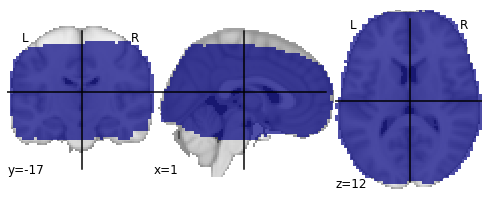

In [3]:
# load in the brain mask and view it
# we need an intersect mask that includes aeronaut and childplay as well
supp_brain_nii=nib.load(base_dir+'data/CartoonLive/ROIs/intersect_mask_standard_Aeronaut_Child_Play.nii.gz') 
supp_brain_masker=NiftiMasker(mask_img=supp_brain_nii)

# fit the brain masker
test_sub=supp_brain_nii
test_fit=supp_brain_masker.fit(test_sub)
affine_mat = test_sub.affine
dimsize = test_sub.header.get_zooms()
coords= np.where(supp_brain_nii.get_fdata())

# plot it! 
plotting.plot_roi(supp_brain_nii)

print('Number of voxels in the whole brain:', np.sum(supp_brain_nii.get_fdata()))

In [4]:
# preset
supp_infant_data_dict = dict() 

# cycle through the movies that we are looking at here 
for movie in ['Aeronaut_firstview','Child_Play']:
    
    if os.path.isfile(base_dir+'data/CartoonLive/supp_movies/%s_infants_wholebrain_data.pkl' % movie.lower()) == False:
        print('Creating preprocessed infant data for %s' % movie)

        # Where is the data is stored? 
        input_dir = '%s/data/Movies/%s/' % (base_dir, movie)

        # Set the expected number of TRs (after accounting for burnout)
        if movie=='Child_Play':
            temp_nTRs=204
        else:
            temp_nTRs=90
            
        # load the participant information
        infant_ppts=pd.read_csv(input_dir+'infant_participants.csv')
        print('Number of infants:', len(infant_ppts))

        # preset
        supp_infant_data = dict()

        # cycle through participants 
        for s, sub in enumerate(infant_ppts.ppt):

            # preprocess the data and zscore it (make sure to use the right number of TRs and brain mask )
            preproc_data=preprocess_data(sub,input_dir,supp_brain_nii,nTRs=temp_nTRs) # remove movement TRs and eye TRs 
            zscored_preproc=stats.zscore(preproc_data,axis=0,nan_policy='omit') # z-score
            supp_infant_data[sub]=zscored_preproc
            
        # Save the data dictionary as a pkl file
        with open(base_dir+'data/CartoonLive/supp_movies/%s_infants_wholebrain_data.pkl' % movie.lower(), "wb") as file:
            pickle.dump(supp_infant_data, file)

    # otherwise, load it in! 
    else:
        print('Loading existing infant data for %s' % movie)

        # Load the dictionary from the pickle file
        with open(base_dir+'data/CartoonLive/supp_movies/%s_infants_wholebrain_data.pkl' % movie.lower(), "rb") as f:
            supp_infant_data = pickle.load(f)
            
    # add to the larger dictionary 
    supp_infant_data_dict[movie]=supp_infant_data

    print()

Loading existing infant data for Aeronaut_firstview

Loading existing infant data for Child_Play



In [5]:
# Now turn it into a stacked data array for the next few analyses 
infant_data_childplay = np.stack([v for v in supp_infant_data_dict['Child_Play'].values()])
infant_data_aeronaut = np.stack([v for v in supp_infant_data_dict['Aeronaut_firstview'].values()])

In [6]:
# Calculate ISC
# Child play
isc_childplay=isc(np.stack(infant_data_childplay).transpose(1,2,0)) # TR x vox x sub
mean_childplay=compute_summary_statistic(isc_childplay, summary_statistic='mean', axis=0)

# Aeronaut
isc_aeronaut=isc(np.stack(infant_data_aeronaut).transpose(1,2,0)) # TR x vox x sub
mean_aeronaut=compute_summary_statistic(isc_aeronaut, summary_statistic='mean', axis=0)


In [7]:
# For each participant, if this data is not yet saved out, save it out 
# cycle through participants
for p, ppt in enumerate(supp_infant_data_dict['Child_Play'].keys()):
    
    # does this subjects ISC file exist?
    if os.path.isfile('%s/data/Movies/Child_Play/temporal_isc/%s_Z.nii.gz' %(base_dir,ppt)) == False:

        print('saving realistic isc for %s'%ppt)

        # Live 
        isc_sub = isc_childplay[p]
        isc_sub_nii = supp_brain_masker.inverse_transform(isc_sub)

        nib.save(isc_sub_nii,'%s/data/Movies/Child_Play/temporal_isc/%s.nii.gz' %(base_dir,ppt))

        # additionally save the fisher Z transformed file
        isc_sub_z_nii = supp_brain_masker.inverse_transform(np.arctanh(isc_childplay[p]))
        nib.save(isc_sub_z_nii,'%s/data/Movies/Child_Play/temporal_isc/%s_Z.nii.gz' %(base_dir,ppt))

for p, ppt in enumerate(supp_infant_data_dict['Aeronaut_firstview'].keys()):
 
    # does this subjects ISC file exist?
    if os.path.isfile('%s/data/Movies/Aeronaut_firstview/temporal_isc/%s_Z.nii.gz' %(base_dir,ppt)) == False:

        print('saving cartoon isc for %s'% ppt)

        # Cartoon 
        isc_sub = isc_aeronaut[p]
        isc_sub_nii = supp_brain_masker.inverse_transform(isc_sub)

        nib.save(isc_sub_nii,'%s/data/Movies/Aeronaut_firstview/temporal_isc/%s.nii.gz' %(base_dir,ppt))

        # additionally save the fisher Z transformed file
        isc_sub_z_nii = supp_brain_masker.inverse_transform(np.arctanh(isc_aeronaut[p]))
        nib.save(isc_sub_z_nii,'%s/data/Movies/Aeronaut_firstview/temporal_isc/%s_Z.nii.gz' %(base_dir,ppt))

# inverse transform the mean ISC maps into whole brain maps 
live_nii=supp_brain_masker.inverse_transform(mean_childplay)
cartoon_nii=supp_brain_masker.inverse_transform(mean_aeronaut)

# save them if they do not already exist
if os.path.isfile('%s/data/Movies/Child_Play/temporal_isc/infants_average.nii.gz' %(base_dir)) == False:
   
    nib.save(live_nii,'%s/data/Movies/Child_Play/temporal_isc/infants_average.nii.gz' %(base_dir))
else:
    print('mean whole brain map already created for realistic movie (child play)')

if os.path.isfile('%s/data/Movies/Aeronaut_firstview/temporal_isc/infants_average.nii.gz' %(base_dir)) == False:
   
    nib.save(cartoon_nii,'%s/data/Movies/Aeronaut_firstview/temporal_isc/infants_average.nii.gz' %(base_dir))
else:
    print('mean whole brain map already created for cartoon movie (aeronaut)')

mean whole brain map already created for realistic movie (child play)
mean whole brain map already created for cartoon movie (aeronaut)


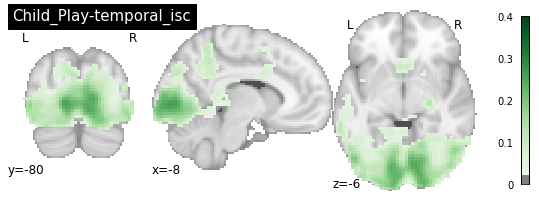

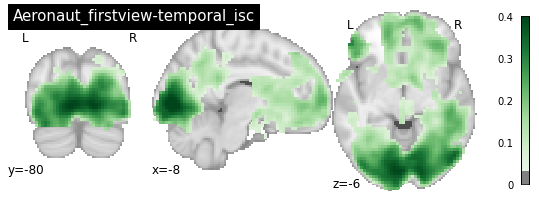

In [8]:
# Now, load in the corrected results after having run FSL randomise (on the command line, see README)
analysis='temporal_isc'
thr_type='tfce_corrp_tstat1' # corrected map 

# cycle through movies 
for movie in ['Child_Play','Aeronaut_firstview']:
    
    # change the threshold / color if we are using a corrected 1-p value map 
    if 'corrp' not in thr_type:
        
        # load the file 
        infant_isc_stat_map = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_infants_%s.nii.gz'%
                                   (movie,analysis,thr_type))
    
        thresh=stats.t.ppf(0.995, len(supp_infant_data_dict[movie])) 
    else:
        # load the corrected file
        infant_isc_corr = nib.load(base_dir+'data/CartoonLive/randomise/%s_%s_infants_%s.nii.gz'%
                                   (movie,analysis,thr_type))
        
        # actually, load the average ISC map 
        infant_isc_uncorr =  nib.load(base_dir+'data/Movies/%s/%s/infants_average.nii.gz' % (movie,analysis))
        
        # threshold it by the corrected file 
        infant_isc_thresholded = infant_isc_uncorr.get_fdata()
        infant_isc_thresholded[infant_isc_corr.get_fdata()<0.95]=0
        
        # turn it into a nifti
        infant_isc_stat_map = nib.Nifti1Image(infant_isc_thresholded,infant_isc_uncorr.affine)
        
        thresh=np.min(infant_isc_thresholded[np.nonzero(infant_isc_thresholded)])
        
    fig = plotting.plot_stat_map(infant_isc_stat_map,threshold=thresh,
                                 cmap='PRGn',vmax=0.4,
                                 title='%s-%s' % (movie,analysis),
                           cut_coords=(-8,-80,-6),draw_cross=False)
    
    fig.savefig(save_plot_dir+'/infant_%s_%s_%s.svg'% (analysis,movie.lower(),thr_type))

V1_combined
Infants live-childplay: M = 0.171, CI = [0.134 to 0.211], p=0.000
Infants cartoon-aeronaut: M = 0.261, CI = [0.173 to 0.340], p=0.000
Infants diff in cartoon-aeronaut vs. live-childplay: M = -0.090, CI = [-0.177 to 0.003], p=0.060

VO_combined
Infants live-childplay: M = 0.091, CI = [0.054 to 0.128], p=0.000
Infants cartoon-aeronaut: M = 0.190, CI = [0.120 to 0.259], p=0.000
Infants diff in cartoon-aeronaut vs. live-childplay: M = -0.099, CI = [-0.175 to -0.024], p=0.020

LO_combined
Infants live-childplay: M = 0.094, CI = [0.071 to 0.117], p=0.000
Infants cartoon-aeronaut: M = 0.168, CI = [0.103 to 0.228], p=0.000
Infants diff in cartoon-aeronaut vs. live-childplay: M = -0.074, CI = [-0.135 to -0.006], p=0.028

Precuneus_standard
Infants live-childplay: M = 0.051, CI = [0.016 to 0.078], p=0.000
Infants cartoon-aeronaut: M = 0.086, CI = [0.047 to 0.128], p=0.000
Infants diff in cartoon-aeronaut vs. live-childplay: M = -0.035, CI = [-0.087 to 0.013], p=0.144

EAC_standard
In

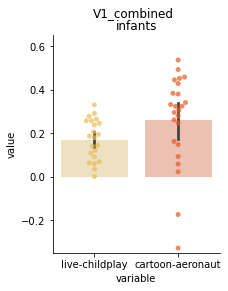

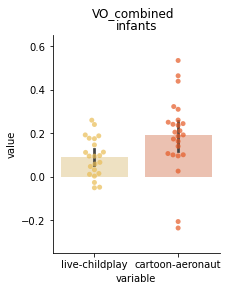

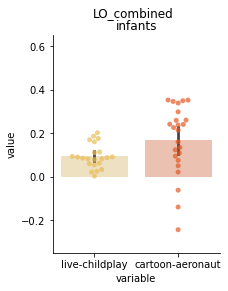

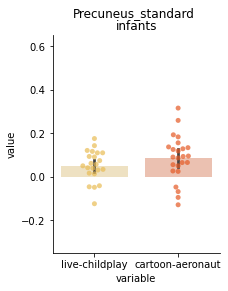

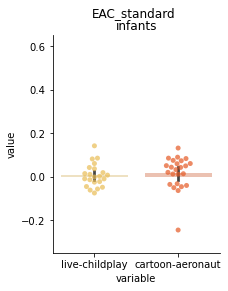

In [10]:
### Now plot the results for the ROIs
analysis='temporal_isc'

# Redefine the ROIs
rois=['V1_combined','VO_combined','LO_combined','Precuneus_standard','EAC_standard']

# cycle through the ROIs
for roi in rois:
    print(roi)
    roi_nii=nib.load(base_dir+'data/CartoonLive/ROIs/'+roi+'.nii.gz')
    
    # fit and transform the data using the brain masker 
    roi_data = supp_brain_masker.transform(roi_nii)[0]
   
    ####### Analysis

    np.random.seed(0)

    #### Infants 
    sub_ages = []
    sub_isc_vols_live = [] 
    sub_isc_vols_cartoon = [] 

    # realistic = child play  
    sub_isc_vols_live = isc_childplay[:,roi_data==1]
    mean_live = np.tanh(np.nanmean(np.arctanh(sub_isc_vols_live),axis=1))

    # cartoon = aeronaut
    sub_isc_vols_cartoon = isc_aeronaut[:,roi_data==1]
    mean_cartoon = np.tanh(np.nanmean(np.arctanh(sub_isc_vols_cartoon),axis=1))
    
    # because child play has less subjects, we need to pad the array for using pandas
    num_pad = len(mean_cartoon) - len(mean_live)
    mean_live =np.hstack((mean_live,np.ones(num_pad)*np.nan))
    
    # make this into a temporary dataframe for plotting 
    temp_df=pd.DataFrame({'live-childplay':mean_live,
                 'cartoon-aeronaut':mean_cartoon})

    ###### Plot 
    fig, ax=plt.subplots(figsize=(3,4))

    fig.suptitle('%s' %(roi))
    ax.set_title('infants')
    ax.set_ylim(-0.35,0.65)
    
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # plot the results ! 
    sns.barplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.4,
                order=['live-childplay','cartoon-aeronaut'],ax=ax)
    sns.swarmplot(x='variable',y='value',data=temp_df.melt(),palette=palette,alpha=0.7,
                order=['live-childplay','cartoon-aeronaut'],ax=ax)

    p_live, CIs=bootstrap_mean(np.array(temp_df['live-childplay']),null_vall=0,nPerm=1000)
    print('Infants live-childplay: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % (np.mean(temp_df['live-childplay']),
                                                                       CIs[0],CIs[1],
                                                                       p_live))

    p_cartoon, CIs=bootstrap_mean(np.array(temp_df['cartoon-aeronaut']),null_vall=0,nPerm=1000)
    print('Infants cartoon-aeronaut: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % (np.mean(temp_df['cartoon-aeronaut']),
                                                                       CIs[0],CIs[1],
                                                                       p_cartoon))
    
    # need to use randomise diff to compare across movies because this is two different samples
    p_diff, mean_val, CIs = randomise_diff_2sample(np.array(temp_df['live-childplay']),
                                                   np.array(temp_df['cartoon-aeronaut']))
    print('Infants diff in cartoon-aeronaut vs. live-childplay: M = %0.3f, CI = [%0.3f to %0.3f], p=%0.3f' % 
                                      (mean_val,CIs[0],CIs[1], p_diff))
                                                   
    fig.savefig('%s/infants_aeronaut_childplay_%s_%s.svg' %(save_plot_dir,roi,analysis))

    print()